In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / ".git").exists():
            return p
    raise RuntimeError("Could not locate project root (no .git found above cwd)")

PROJECT_ROOT = _find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments" / "concept_drift"


# Concept Drift Detection on Synthetic Artifacts (Distribution Test: MMD / Energy Distance)

This notebook runs the distribution-drift pipeline from `concept_drift_detection-distribution.ipynb`
(Method 2: MMD/Energy distance) against the synthetic artifacts generated in
`data drift testing on syntetic data.ipynb`, following the same manifest-driven, per-method /
per-severity / resumable-checkpoint structure as
`concept_drift_detection_with_syntetic_data-disc.ipynb`.

Unlike the discriminator (Method 1), this test needs no classifier and no held-out split: it
compares the **train-split** feature distributions of adjacent years directly, using:
- **MMD (Gaussian/RBF kernel, linear-time estimator)**
- **MMD (Laplacian kernel, linear-time estimator)**
- **Energy Distance (linear-time estimator)**

Each statistic is tested two ways:
- **vs. zero**, via a closed-form asymptotic z-test (Gretton et al., 2012, *A Kernel Two-Sample
  Test*, §6) — at full-dataset scale (millions of pixels/year) this saturates to "significant"
  for nearly every pair, so it's kept only for reference.
- **vs. a within-year baseline** — each year's pixels are independently split in half and the
  same statistics are computed *between the halves* (a genuine no-drift/H0 case at the same
  sample scale). This becomes the reference for a **relevance z-test**
  (`stat - baseline` instead of `stat - 0`), which is the informative test: it actually
  discriminates between artifacts/pairs instead of uniformly rejecting H0.

p-values across all pairs and statistics for a given artifact are corrected for multiple
comparisons via **Benjamini-Hochberg FDR** (`scipy.stats.false_discovery_control`); the same
correction is applied separately to the per-band KS tests (see below). Correction is done
per-artifact (across that artifact's own pairs × statistics) rather than globally across all
18 synthetic artifacts, so one artifact's tests don't dilute another's FDR budget.

**Detection score.** To plot/compare artifacts on one axis (mirroring the discriminator
notebook's AUC), each pair is summarized as `detection_score = -log10(min BH-adjusted relevance
q-value across the three statistics)` — higher means stronger evidence of drift beyond the
within-year noise floor.

**Per-band decomposition.** MMD/Energy are joint statistics over all S2 bands, so a large value
can't be attributed to *which* band drifted, or whether it's a mean-shift vs. a pure
spread/shape change. For each pair and band, a KS statistic, standardized mean shift, and std
ratio are computed on a bounded subsample so the per-band p-values stay informative.

Each method section runs every `(mode, severity)` artifact available for that method — one row
per `(method, mode, severity)` combination, identified by `artifact_label`. Results are
grouped/plotted by severity to show a detection-power-vs-magnitude curve.

**Resumability:** every `(artifact, year-pair)` result is checkpointed to
`distribution_checkpoints_synthetic_drift/distribution_results.pkl` (pair-level stats) and
`distribution_band_results.pkl` (per-band stats) as soon as it's computed. Re-running the
notebook picks up where it left off — already-computed pairs print `CACHED: ...` and are not
recomputed. Call `clear_results_checkpoint()` if you change the test pipeline and want to force
a full recompute.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.stats import norm, false_discovery_control, ks_2samp

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Paths
split_path = str(PROJECT_ROOT / "data_split.npz")
manifest_json_path = PROJECT_ROOT / "synthetic_drift_data" / "synthetic_generation_manifest.json"
manifest_csv_path = PROJECT_ROOT / "synthetic_drift_data" / "synthetic_generation_manifest.csv"
original_data_path = str(PROJECT_ROOT / "training_data_with_features.zarr")  # unmodified source, used as a reference baseline

# Checkpointing (resumability): every (artifact, year-pair) result is persisted here as soon
# as it's computed, so an interrupted/restarted run can skip already-completed pairs. Per-band
# decomposition rows are checkpointed separately since they're keyed one level deeper (band).
CHECKPOINT_DIR = EXPERIMENTS_DIR / "distribution_checkpoints_synthetic_drift"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CHECKPOINT_PATH = CHECKPOINT_DIR / "distribution_results.pkl"
BAND_CHECKPOINT_PATH = CHECKPOINT_DIR / "distribution_band_results.pkl"

# Runtime config
SAMPLE_FRACTION = 1.0          # Fraction of the train split's pixels to load per artifact (1.0 = full split)
MAX_SAMPLES_PER_YEAR = None    # Further cap on per-year pixels used for the MMD/Energy statistics; None = use everything sampled above
SIGMA_CALIBRATION_SIZE = 6000  # sample size used to estimate kernel bandwidths (independent of main-test sample size)
ALPHA = 0.05
CORRECTION_METHOD = "fdr_bh"   # Benjamini-Hochberg, applied per artifact across its pairs x statistics via scipy.stats.false_discovery_control
BASELINE_YEAR_REPEATS = 2      # random half-splits per year (prev + curr) used to estimate the self-vs-self noise floor
BAND_SAMPLE_SIZE = 200_000     # bounded per-year subsample for per-band KS / effect-size stats
SHOW_BAND_HEATMAPS = True      # set False to skip the per-artifact per-band heatmap plots (there's one per artifact)

# Load manifest (consume-only workflow)
if manifest_json_path.exists():
    with open(manifest_json_path, "r", encoding="utf-8") as handle:
        manifest_obj = json.load(handle)
    manifest_df = pd.DataFrame(manifest_obj.get("rows", []))
elif manifest_csv_path.exists():
    manifest_df = pd.read_csv(manifest_csv_path)
else:
    raise FileNotFoundError(
        "Synthetic manifest not found. Expected one of:\n"
        f"  - {manifest_json_path}\n"
        f"  - {manifest_csv_path}\n"
        "Generate artifacts first in 'data drift testing on syntetic data.ipynb'."
    )

required_cols = {"mode", "method", "zarr_path", "metadata_path"}
missing_cols = sorted(required_cols - set(manifest_df.columns))
if missing_cols:
    raise ValueError(f"Manifest is missing required columns: {missing_cols}")

if manifest_df.empty:
    raise ValueError("Manifest contains no artifact rows.")

manifest_df = manifest_df.copy()

# Older manifests (pre severity-sweep) won't have these columns; default them so the rest of
# this notebook can treat every manifest uniformly.
for optional_col, default_value in [("severity", None), ("pixel_fraction", 1.0), ("class_filter", None)]:
    if optional_col not in manifest_df.columns:
        manifest_df[optional_col] = default_value


def _severity_display(severity):
    """Render a severity value (dict for mean_variance_shift, scalar for others) as a short label."""
    if isinstance(severity, dict):
        return ", ".join(f"{k}={v}" for k, v in severity.items())
    if severity is None or (isinstance(severity, float) and np.isnan(severity)):
        return "n/a"
    return str(severity)


manifest_df["severity_display"] = manifest_df["severity"].apply(_severity_display)

# One artifact = one (method, mode, severity) combination now that the generator sweeps a
# severity list per method; the label must include severity or rows silently collide.
manifest_df["artifact_label"] = (
    manifest_df["method"] + " | " + manifest_df["mode"] + " | " + manifest_df["severity_display"]
)
manifest_df = manifest_df.sort_values(["method", "mode"]).reset_index(drop=True)

# Load data splits (only the train split is used here - the distribution test compares
# train-split feature distributions directly, it doesn't need a held-out val/test split the
# way the discriminator does)
splits = np.load(split_path)
train_pixel_indices = splits["train_pixel_indices"]

print(f"Loaded manifest rows: {len(manifest_df)}")
print(f"Train split size: {len(train_pixel_indices):,}")
display(manifest_df[["method", "mode", "severity_display", "pixel_fraction", "class_filter", "zarr_path", "metadata_path"]])

Loaded manifest rows: 18
Train split size: 5,597,776


,method,mode,severity_display,pixel_fraction,class_filter,zarr_path,metadata_path
0,covariance_shift,baseline_replication,0.05,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
1,covariance_shift,baseline_replication,0.15,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
2,covariance_shift,baseline_replication,0.3,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
3,covariance_shift,per_year_original,0.05,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
4,covariance_shift,per_year_original,0.15,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
5,covariance_shift,per_year_original,0.3,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
6,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
7,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.0",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
8,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
9,mean_variance_shift,per_year_original,"mean_shift=0.0, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...


In [4]:
# Manifest diagnostics
method_order = ["mean_variance_shift", "covariance_shift", "noise_injection"]
mode_order = ["baseline_replication", "per_year_original"]

summary_df = (
    manifest_df.groupby(["method", "mode"], dropna=False)
    .size()
    .rename("n_artifacts")
    .reset_index()
    .sort_values(["method", "mode"])
    .reset_index(drop=True)
)

display(summary_df)

detail_df = (
    manifest_df.groupby(["method", "mode", "severity_display"], dropna=False)
    .size()
    .rename("n_artifacts")
    .reset_index()
    .sort_values(["method", "mode", "severity_display"])
    .reset_index(drop=True)
)

display(detail_df)

def _resolve_manifest_path(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_ROOT / p

missing_files = []
for _, row in manifest_df.iterrows():
    zarr_ok = _resolve_manifest_path(row["zarr_path"]).exists()
    meta_ok = _resolve_manifest_path(row["metadata_path"]).exists()
    if not (zarr_ok and meta_ok):
        missing_files.append({
            "method": row["method"],
            "mode": row["mode"],
            "severity_display": row["severity_display"],
            "zarr_exists": zarr_ok,
            "metadata_exists": meta_ok,
        })

if missing_files:
    missing_df = pd.DataFrame(missing_files)
    display(missing_df)
    raise FileNotFoundError("Some artifact files from manifest are missing.")

print("All manifest-referenced artifact files are present.")

,method,mode,n_artifacts
0,covariance_shift,baseline_replication,3
1,covariance_shift,per_year_original,3
2,mean_variance_shift,baseline_replication,3
3,mean_variance_shift,per_year_original,3
4,noise_injection,baseline_replication,3
5,noise_injection,per_year_original,3


,method,mode,severity_display,n_artifacts
0,covariance_shift,baseline_replication,0.05,1
1,covariance_shift,baseline_replication,0.15,1
2,covariance_shift,baseline_replication,0.3,1
3,covariance_shift,per_year_original,0.05,1
4,covariance_shift,per_year_original,0.15,1
5,covariance_shift,per_year_original,0.3,1
6,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",1
7,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.0",1
8,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.15",1
9,mean_variance_shift,per_year_original,"mean_shift=0.0, variance_scale=1.15",1


All manifest-referenced artifact files are present.


In [5]:
RESULTS_CHECKPOINT_COLUMNS = [
    "method", "mode", "severity", "severity_display", "pixel_fraction", "class_filter",
    "artifact_label", "zarr_path", "pair", "year_t_minus_1", "year_t",
    "sample_fraction", "max_samples_per_year",
    "n_prev", "n_curr", "n_used", "sigma_rbf", "bandwidth_lap",
    "mmd_rbf_stat", "mmd_rbf_se", "mmd_rbf_z", "mmd_rbf_pvalue",
    "mmd_lap_stat", "mmd_lap_se", "mmd_lap_z", "mmd_lap_pvalue",
    "energy_stat", "energy_se", "energy_z", "energy_pvalue",
    "baseline_rbf_stat", "baseline_rbf_se",
    "baseline_lap_stat", "baseline_lap_se",
    "baseline_energy_stat", "baseline_energy_se",
    "mmd_rbf_z_relevance", "mmd_rbf_pvalue_relevance",
    "mmd_lap_z_relevance", "mmd_lap_pvalue_relevance",
    "energy_z_relevance", "energy_pvalue_relevance",
    "time_sec", "changed_years", "perturb_year_values",
]

BAND_CHECKPOINT_COLUMNS = [
    "method", "mode", "severity", "severity_display", "class_filter", "artifact_label",
    "pair", "year_t_minus_1", "year_t", "sample_fraction", "max_samples_per_year",
    "band", "band_idx", "n_used", "ks_stat", "ks_pvalue", "mean_shift_std", "std_ratio",
]


def load_results_checkpoint(path):
    """Load an on-disk results checkpoint, or an empty frame with the expected schema."""
    columns = RESULTS_CHECKPOINT_COLUMNS if path == RESULTS_CHECKPOINT_PATH else BAND_CHECKPOINT_COLUMNS
    if path.exists():
        return pd.read_pickle(path)
    return pd.DataFrame(columns=columns)


def save_results_checkpoint(df, path):
    """Write a checkpoint atomically (tmp file + replace) so a crash mid-write can't corrupt it."""
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_pickle(tmp_path)
    tmp_path.replace(path)


def clear_results_checkpoint():
    """Delete both on-disk checkpoints and reset the in-memory caches. Call this after changing the test pipeline."""
    global CHECKPOINT_DF, BAND_CHECKPOINT_DF
    for path in (RESULTS_CHECKPOINT_PATH, BAND_CHECKPOINT_PATH):
        if path.exists():
            path.unlink()
    CHECKPOINT_DF = pd.DataFrame(columns=RESULTS_CHECKPOINT_COLUMNS)
    BAND_CHECKPOINT_DF = pd.DataFrame(columns=BAND_CHECKPOINT_COLUMNS)
    print(f"Cleared results checkpoints at {RESULTS_CHECKPOINT_PATH} and {BAND_CHECKPOINT_PATH}")


def _match_col(series, value):
    """Cache-key equality that treats None/NaN as a single bucket (plain `==` would silently
    never match a cached None, causing every row to look like a permanent cache miss)."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return series.isna()
    return series == value


def prepare_features_for_year(ds_subset, year_idx):
    """Prepare per-pixel features for a given year index using S2 bands only."""
    if year_idx == 0:
        return None, None

    valid_mask = ds_subset.disturbances[:, year_idx].values != 255

    s2_data = ds_subset.s2_bands.values  # shape (n_pixels, n_years, n_bands)
    s2_t = s2_data[:, year_idx, :].copy()  # shape (n_pixels, n_bands)

    # Vectorized NaN imputation: per-pixel, per-band mean across years
    nan_mask = np.isnan(s2_t)
    if np.any(nan_mask):
        band_means = np.nanmean(s2_data, axis=1)  # shape (n_pixels, n_bands)
        s2_t[nan_mask] = band_means[nan_mask]

    X = s2_t
    y = ds_subset.disturbances[:, year_idx].values

    # Combined mask: valid disturbance + binary label + finite features
    keep_mask = valid_mask & np.isin(y, [0, 1]) & np.all(np.isfinite(X), axis=1)
    X = X[keep_mask]
    y = y[keep_mask]

    if len(X) == 0:
        return None, None

    return X, y


def _sample_indices(indices, sample_fraction, rng_seed=RANDOM_STATE):
    if sample_fraction >= 1.0:
        return indices
    rng_local = np.random.default_rng(rng_seed)
    sample_size = max(1, int(len(indices) * sample_fraction))
    return rng_local.choice(indices, size=sample_size, replace=False)


def _subsample_rows(X, max_n, rng):
    if X is None or max_n is None:
        return X
    if len(X) <= max_n:
        return X
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X[idx]


def _random_half_split(X, rng):
    """Split X into two disjoint random halves (drops the last row if n is odd).
    Used to build a genuine H0 (no-drift) reference: two halves of the SAME year."""
    n = len(X)
    half = n // 2
    idx = rng.permutation(n)
    return X[idx[:half]], X[idx[half:2 * half]]


def estimate_rbf_sigma(X, Y, calib_size, rng, eps=1e-8):
    Xc = _subsample_rows(X, calib_size, rng)
    Yc = _subsample_rows(Y, calib_size, rng)
    Z = np.vstack([Xc, Yc])
    dists = pdist(Z, metric="euclidean")
    med = np.median(dists)
    if not np.isfinite(med) or med <= 0:
        med = 1.0
    return float(max(med, eps))


def estimate_laplacian_bandwidth(X, Y, calib_size, rng, eps=1e-8):
    Xc = _subsample_rows(X, calib_size, rng)
    Yc = _subsample_rows(Y, calib_size, rng)
    Z = np.vstack([Xc, Yc])
    dists = pdist(Z, metric="cityblock")  # L1 distances
    med = np.median(dists)
    if not np.isfinite(med) or med <= 0:
        med = 1.0
    return float(max(med, eps))


def mmd_rbf_terms(X, Y, sigma, rng):
    """Per-matched-pair terms h_i for the linear-time MMD^2 estimator (Gretton et al. 2012, eq. 6-7), RBF kernel."""
    n = min(len(X), len(Y))
    if n < 4:
        return np.array([])

    if n % 2 == 1:
        n -= 1

    x_idx = rng.choice(len(X), size=n, replace=False)
    y_idx = rng.choice(len(Y), size=n, replace=False)
    Xn = X[x_idx]
    Yn = Y[y_idx]

    half = n // 2
    x1, x2 = Xn[:half], Xn[half:]
    y1, y2 = Yn[:half], Yn[half:]

    gamma = 1.0 / (2.0 * sigma * sigma)

    k_xx = np.exp(-gamma * np.sum((x1 - x2) ** 2, axis=1))
    k_yy = np.exp(-gamma * np.sum((y1 - y2) ** 2, axis=1))
    k_xy = np.exp(-gamma * np.sum((x1 - y2) ** 2, axis=1))
    k_yx = np.exp(-gamma * np.sum((x2 - y1) ** 2, axis=1))

    return k_xx + k_yy - k_xy - k_yx


def mmd_laplacian_terms(X, Y, bandwidth, rng):
    """Per-matched-pair terms h_i for the linear-time MMD^2 estimator, Laplacian kernel."""
    n = min(len(X), len(Y))
    if n < 4:
        return np.array([])

    if n % 2 == 1:
        n -= 1

    x_idx = rng.choice(len(X), size=n, replace=False)
    y_idx = rng.choice(len(Y), size=n, replace=False)
    Xn = X[x_idx]
    Yn = Y[y_idx]

    half = n // 2
    x1, x2 = Xn[:half], Xn[half:]
    y1, y2 = Yn[:half], Yn[half:]

    d_xx = np.sum(np.abs(x1 - x2), axis=1)
    d_yy = np.sum(np.abs(y1 - y2), axis=1)
    d_xy = np.sum(np.abs(x1 - y2), axis=1)
    d_yx = np.sum(np.abs(x2 - y1), axis=1)

    k_xx = np.exp(-d_xx / bandwidth)
    k_yy = np.exp(-d_yy / bandwidth)
    k_xy = np.exp(-d_xy / bandwidth)
    k_yx = np.exp(-d_yx / bandwidth)

    return k_xx + k_yy - k_xy - k_yx


def energy_distance_terms(X, Y, rng):
    """Per-matched-pair terms h_i for the linear-time energy-distance estimator (Szekely & Rizzo)."""
    n = min(len(X), len(Y))
    if n < 4:
        return np.array([])

    if n % 2 == 1:
        n -= 1

    x_idx = rng.choice(len(X), size=n, replace=False)
    y_idx = rng.choice(len(Y), size=n, replace=False)
    Xn = X[x_idx]
    Yn = Y[y_idx]

    half = n // 2
    x1, x2 = Xn[:half], Xn[half:]
    y1, y2 = Yn[:half], Yn[half:]

    e_xy = np.linalg.norm(x1 - y1, axis=1)
    e_xx = np.linalg.norm(x1 - x2, axis=1)
    e_yy = np.linalg.norm(y1 - y2, axis=1)

    return 2.0 * e_xy - e_xx - e_yy


def asymptotic_z_test(h_terms):
    """Closed-form drift test for any statistic expressed as a mean of i.i.d. matched-pair terms
    (linear-time MMD, Gretton et al. 2012 Sec. 6; the same CLT argument applies to the linear-time
    energy-distance estimator). Avoids permutation resampling, so it stays O(n) per pair even at
    full-dataset scale."""
    h_terms = np.asarray(h_terms, dtype=float)
    n_terms = len(h_terms)
    if n_terms < 2:
        return np.nan, np.nan, np.nan, np.nan

    stat = float(np.mean(h_terms))
    se = float(np.std(h_terms, ddof=1) / np.sqrt(n_terms))
    if not np.isfinite(se) or se <= 0:
        return stat, se, np.nan, np.nan

    z = stat / se
    p_value = float(1.0 - norm.cdf(z))  # one-sided: statistic ~0 under H0, > 0 under drift
    return stat, se, z, p_value


def relevance_z_test(stat, se, baseline_stat, baseline_se):
    """Test whether `stat` exceeds the within-year (self-vs-self) noise floor `baseline_stat`,
    instead of testing against exactly zero. `stat` and `baseline_stat` are estimated from
    disjoint samples, so this is a two-sample z-test on their difference with combined SE."""
    if not all(np.isfinite(v) for v in (stat, se, baseline_stat, baseline_se)):
        return np.nan, np.nan
    combined_se = float(np.sqrt(se ** 2 + baseline_se ** 2))
    if combined_se <= 0:
        return np.nan, np.nan
    z = (stat - baseline_stat) / combined_se
    p_value = float(1.0 - norm.cdf(z))
    return z, p_value


def _bh_correct(df, pvalue_cols, alpha):
    """Apply BH-FDR correction across the given p-value columns (flattened together) and
    write back `*_pvalue_adj` / `*_reject_h0` columns, in place. Applied per-artifact, across
    that artifact's own pairs x statistics - mixing artifacts into one correction would let an
    18-artifact run dilute the FDR budget available to any single artifact's tests."""
    stacked = df[pvalue_cols].to_numpy().ravel()
    valid_mask = np.isfinite(stacked)
    adjusted = np.full_like(stacked, np.nan)
    if valid_mask.any():
        adjusted[valid_mask] = false_discovery_control(stacked[valid_mask], method="bh")
    adjusted = adjusted.reshape(df[pvalue_cols].shape)
    for i, col in enumerate(pvalue_cols):
        adj_col = col + "_adj"
        reject_col = col.replace("_pvalue", "_reject_h0")
        df[adj_col] = adjusted[:, i]
        df[reject_col] = adjusted[:, i] <= alpha


def to_dist_display(df, id_cols):
    """Trim a results dataframe down to identifying columns plus the headline stats: the three
    raw statistics and the single `DriftScore` summary (-log10 min BH-adjusted relevance
    q-value) used for plotting/comparison, mirroring the discriminator notebook's `to_auc_display`.
    """
    cols = [c for c in id_cols if c in df.columns] + [
        "mmd_rbf_stat", "mmd_lap_stat", "energy_stat", "detection_score",
    ]
    return df[[c for c in cols if c in df.columns]].rename(columns={"detection_score": "DriftScore"})


def plot_artifact_drift(pair_df, title_suffix="", reference_score=None):
    """Plot DriftScore (-log10 min BH-adjusted relevance q-value) per year pair.

    reference_score, when given, is a sequence aligned to pair_df's rows - the
    original-unmodified-data DriftScore for the same year pairs - drawn as a dashed reference
    line so a per_year_original artifact's perturbed-pair results can be read against it.
    """
    if len(pair_df) == 0:
        print("No rows to plot for this artifact.")
        return

    x = np.arange(len(pair_df))
    plt.figure(figsize=(10, 4.5))
    plt.plot(x, pair_df["detection_score"], marker="o", label="DriftScore")

    if reference_score is not None:
        plt.plot(x, reference_score, marker="d", linestyle="--", color="gray", label="DriftScore (original, unmodified)")

    plt.axhline(-np.log10(ALPHA), linestyle=":", color="red", alpha=0.6, label=f"q={ALPHA} threshold")
    plt.xticks(x, pair_df["pair"], rotation=45, ha="right")
    plt.ylabel("DriftScore (-log10 min BH q-value, vs. baseline)")
    plt.title(f"Adjacent-Year Distribution Drift Score{title_suffix}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_band_heatmap(band_df, artifact_label):
    """Per-band KS statistic + standardized mean shift heatmaps for one artifact, mirroring the
    original distribution notebook's decomposition: a band with a high KS statistic but a
    mean_shift_std near 0 has changed in spread/shape rather than location - a case the MMD/Energy
    joint statistics (and a linear discriminator) can't attribute to a specific cause."""
    if len(band_df) == 0:
        return

    band_labels = band_df.sort_values("band_idx")["band"].drop_duplicates().tolist()
    pair_order = band_df.sort_values("year_t")["pair"].drop_duplicates().tolist()

    ks_pivot = band_df.pivot(index="band", columns="pair", values="ks_stat").reindex(
        index=band_labels, columns=pair_order
    )
    mean_shift_pivot = band_df.pivot(index="band", columns="pair", values="mean_shift_std").reindex(
        index=band_labels, columns=pair_order
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    im0 = axes[0].imshow(ks_pivot.values, aspect="auto", cmap="viridis")
    axes[0].set_xticks(range(len(ks_pivot.columns)))
    axes[0].set_xticklabels(ks_pivot.columns, rotation=45, ha="right")
    axes[0].set_yticks(range(len(ks_pivot.index)))
    axes[0].set_yticklabels(ks_pivot.index)
    axes[0].set_title("KS statistic by band x pair")
    for i in range(ks_pivot.shape[0]):
        for j in range(ks_pivot.shape[1]):
            val = ks_pivot.values[i, j]
            if np.isfinite(val):
                axes[0].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color="white")
    fig.colorbar(im0, ax=axes[0], label="KS statistic")

    finite_shifts = mean_shift_pivot.values[np.isfinite(mean_shift_pivot.values)]
    max_abs = float(np.max(np.abs(finite_shifts))) if finite_shifts.size > 0 else 1.0
    im1 = axes[1].imshow(mean_shift_pivot.values, aspect="auto", cmap="RdBu_r", vmin=-max_abs, vmax=max_abs)
    axes[1].set_xticks(range(len(mean_shift_pivot.columns)))
    axes[1].set_xticklabels(mean_shift_pivot.columns, rotation=45, ha="right")
    axes[1].set_yticks(range(len(mean_shift_pivot.index)))
    axes[1].set_yticklabels(mean_shift_pivot.index)
    axes[1].set_title("Standardized mean shift by band x pair")
    for i in range(mean_shift_pivot.shape[0]):
        for j in range(mean_shift_pivot.shape[1]):
            val = mean_shift_pivot.values[i, j]
            if np.isfinite(val):
                axes[1].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im1, ax=axes[1], label="(mean_t - mean_t-1) / pooled_std")

    plt.suptitle(f"Per-Band Drift Decomposition | {artifact_label} (n={BAND_SAMPLE_SIZE:,} subsample per year)")
    plt.tight_layout()
    plt.show()


def run_distribution_test_on_dataset(
    zarr_path,
    method,
    mode,
    artifact_label,
    severity=None,
    severity_display=None,
    pixel_fraction=None,
    class_filter=None,
    changed_years=None,
    perturb_year_values=None,
    sample_fraction=SAMPLE_FRACTION,
    max_samples_per_year=MAX_SAMPLES_PER_YEAR,
):
    """Run the MMD/Energy distribution-drift pipeline against any zarr dataset, on its train split.

    Shared by synthetic artifacts (via run_distribution_test_for_artifact) and the unmodified
    original dataset (the per_year_original reference) so both paths test exactly the same way.

    Resumability: each (artifact_label, pair, sample_fraction, max_samples_per_year) result is
    looked up in the on-disk checkpoints (CHECKPOINT_DF, BAND_CHECKPOINT_DF) before doing any
    work for that pair. A hit skips feature prep and statistic computation entirely; a miss
    computes the pair as before, then appends the new rows to both checkpoints and saves them
    to disk immediately. BH-FDR correction is (re)applied every call across the full set of
    this artifact's pairs, since it depends on the whole family regardless of which rows came
    from cache vs. were freshly computed.
    """
    global CHECKPOINT_DF, BAND_CHECKPOINT_DF

    zarr_path = Path(zarr_path)
    if not zarr_path.is_absolute():
        zarr_path = PROJECT_ROOT / zarr_path

    ds_artifact = xr.open_zarr(zarr_path)
    year_values = ds_artifact.year.values
    n_years = len(year_values)
    n_pairs = n_years - 2
    band_labels = [str(b) for b in ds_artifact.s2_band.values]

    train_sample = _sample_indices(train_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE)
    ds_train = ds_artifact.isel(pixel=train_sample)

    print(f"Artifact: {artifact_label}")
    print(f"Dataset: {zarr_path}")
    print(f"Pairs to evaluate: {n_pairs}")

    pair_results = []
    band_results = []
    skipped_pairs = []
    start_time = time.time()

    for pair_idx, idx_curr in enumerate(range(2, n_years), start=1):
        idx_prev = idx_curr - 1
        year_prev = int(year_values[idx_prev])
        year_curr = int(year_values[idx_curr])
        pair_name = f"{year_prev} vs {year_curr}"

        pair_start = time.time()
        print(f"\n[{pair_idx}/{n_pairs}] {pair_name}")

        pair_mask = (
            (CHECKPOINT_DF["artifact_label"] == artifact_label)
            & (CHECKPOINT_DF["pair"] == pair_name)
            & (CHECKPOINT_DF["sample_fraction"] == sample_fraction)
            & (_match_col(CHECKPOINT_DF["max_samples_per_year"], max_samples_per_year))
        )
        pair_cache_hit = CHECKPOINT_DF[pair_mask]
        band_mask = (
            (BAND_CHECKPOINT_DF["artifact_label"] == artifact_label)
            & (BAND_CHECKPOINT_DF["pair"] == pair_name)
            & (BAND_CHECKPOINT_DF["sample_fraction"] == sample_fraction)
            & (_match_col(BAND_CHECKPOINT_DF["max_samples_per_year"], max_samples_per_year))
        )
        band_cache_hit = BAND_CHECKPOINT_DF[band_mask]

        if len(pair_cache_hit) > 0 and len(band_cache_hit) == len(band_labels):
            cached_row = pair_cache_hit.iloc[-1].to_dict()
            pair_results.append(cached_row)
            band_results.extend(band_cache_hit.to_dict("records"))
            print(
                f"  CACHED: MMD-G={cached_row['mmd_rbf_stat']:.6f} | MMD-L={cached_row['mmd_lap_stat']:.6f} "
                f"| Energy={cached_row['energy_stat']:.6f}"
            )
            continue

        rng = np.random.default_rng(RANDOM_STATE + pair_idx)

        X_prev, _ = prepare_features_for_year(ds_train, idx_prev)
        X_curr, _ = prepare_features_for_year(ds_train, idx_curr)

        if X_prev is None or X_curr is None:
            skipped_pairs.append((pair_name, "missing features after filtering"))
            print("  SKIP: missing features")
            continue

        if X_prev.shape[1] != X_curr.shape[1]:
            skipped_pairs.append((pair_name, "feature dimension mismatch"))
            print("  SKIP: feature mismatch")
            continue

        X_prev_s = _subsample_rows(X_prev, max_samples_per_year, rng)
        X_curr_s = _subsample_rows(X_curr, max_samples_per_year, rng)

        print(f"  Using n_prev={len(X_prev_s):,}, n_curr={len(X_curr_s):,}")

        sigma_rbf = estimate_rbf_sigma(X_prev_s, X_curr_s, SIGMA_CALIBRATION_SIZE, rng)
        bandwidth_lap = estimate_laplacian_bandwidth(X_prev_s, X_curr_s, SIGMA_CALIBRATION_SIZE, rng)

        mmd_rbf_stat, mmd_rbf_se, mmd_rbf_z, mmd_rbf_p = asymptotic_z_test(
            mmd_rbf_terms(X_prev_s, X_curr_s, sigma_rbf, rng)
        )
        mmd_lap_stat, mmd_lap_se, mmd_lap_z, mmd_lap_p = asymptotic_z_test(
            mmd_laplacian_terms(X_prev_s, X_curr_s, bandwidth_lap, rng)
        )
        energy_stat, energy_se, energy_z, energy_p = asymptotic_z_test(
            energy_distance_terms(X_prev_s, X_curr_s, rng)
        )

        # --- Within-year baseline (null-distribution) reference ---
        baseline_stats = {"mmd_rbf": [], "mmd_lap": [], "energy": []}
        baseline_ses = {"mmd_rbf": [], "mmd_lap": [], "energy": []}
        for X_year in (X_prev_s, X_curr_s):
            for _ in range(BASELINE_YEAR_REPEATS):
                Xb1, Xb2 = _random_half_split(X_year, rng)
                b_rbf_stat, b_rbf_se, _, _ = asymptotic_z_test(mmd_rbf_terms(Xb1, Xb2, sigma_rbf, rng))
                b_lap_stat, b_lap_se, _, _ = asymptotic_z_test(mmd_laplacian_terms(Xb1, Xb2, bandwidth_lap, rng))
                b_energy_stat, b_energy_se, _, _ = asymptotic_z_test(energy_distance_terms(Xb1, Xb2, rng))
                baseline_stats["mmd_rbf"].append(b_rbf_stat)
                baseline_stats["mmd_lap"].append(b_lap_stat)
                baseline_stats["energy"].append(b_energy_stat)
                baseline_ses["mmd_rbf"].append(b_rbf_se)
                baseline_ses["mmd_lap"].append(b_lap_se)
                baseline_ses["energy"].append(b_energy_se)

        baseline_rbf_stat = float(np.mean(baseline_stats["mmd_rbf"]))
        baseline_rbf_se = float(np.sqrt(np.mean(np.square(baseline_ses["mmd_rbf"]))))
        baseline_lap_stat = float(np.mean(baseline_stats["mmd_lap"]))
        baseline_lap_se = float(np.sqrt(np.mean(np.square(baseline_ses["mmd_lap"]))))
        baseline_energy_stat = float(np.mean(baseline_stats["energy"]))
        baseline_energy_se = float(np.sqrt(np.mean(np.square(baseline_ses["energy"]))))

        mmd_rbf_z_rel, mmd_rbf_p_rel = relevance_z_test(mmd_rbf_stat, mmd_rbf_se, baseline_rbf_stat, baseline_rbf_se)
        mmd_lap_z_rel, mmd_lap_p_rel = relevance_z_test(mmd_lap_stat, mmd_lap_se, baseline_lap_stat, baseline_lap_se)
        energy_z_rel, energy_p_rel = relevance_z_test(energy_stat, energy_se, baseline_energy_stat, baseline_energy_se)

        # --- Per-band univariate decomposition ---
        X_prev_band = _subsample_rows(X_prev_s, BAND_SAMPLE_SIZE, rng)
        X_curr_band = _subsample_rows(X_curr_s, BAND_SAMPLE_SIZE, rng)
        new_band_rows = []
        for band_idx, band_label in enumerate(band_labels):
            prev_vals = X_prev_band[:, band_idx]
            curr_vals = X_curr_band[:, band_idx]

            ks_stat, ks_p = ks_2samp(prev_vals, curr_vals)

            prev_std = float(np.std(prev_vals, ddof=1))
            curr_std = float(np.std(curr_vals, ddof=1))
            pooled_std = float(np.sqrt((prev_std ** 2 + curr_std ** 2) / 2.0))
            mean_shift_std = float((np.mean(curr_vals) - np.mean(prev_vals)) / pooled_std) if pooled_std > 0 else np.nan
            std_ratio = float(curr_std / prev_std) if prev_std > 0 else np.nan

            new_band_rows.append({
                "method": method, "mode": mode, "severity": severity,
                "severity_display": severity_display, "class_filter": class_filter,
                "artifact_label": artifact_label,
                "pair": pair_name, "year_t_minus_1": year_prev, "year_t": year_curr,
                "sample_fraction": sample_fraction, "max_samples_per_year": max_samples_per_year,
                "band": band_label, "band_idx": band_idx,
                "n_used": int(min(len(prev_vals), len(curr_vals))),
                "ks_stat": float(ks_stat), "ks_pvalue": float(ks_p),
                "mean_shift_std": mean_shift_std, "std_ratio": std_ratio,
            })
        band_results.extend(new_band_rows)

        BAND_CHECKPOINT_DF = pd.concat(
            [BAND_CHECKPOINT_DF, pd.DataFrame(new_band_rows)], ignore_index=True
        )
        save_results_checkpoint(BAND_CHECKPOINT_DF, BAND_CHECKPOINT_PATH)

        pair_time = time.time() - pair_start

        row = {
            "method": method, "mode": mode, "severity": severity,
            "severity_display": severity_display, "pixel_fraction": pixel_fraction,
            "class_filter": class_filter, "artifact_label": artifact_label,
            "zarr_path": str(zarr_path), "pair": pair_name,
            "year_t_minus_1": year_prev, "year_t": year_curr,
            "sample_fraction": sample_fraction, "max_samples_per_year": max_samples_per_year,
            "n_prev": int(len(X_prev)), "n_curr": int(len(X_curr)), "n_used": int(min(len(X_prev_s), len(X_curr_s))),
            "sigma_rbf": float(sigma_rbf), "bandwidth_lap": float(bandwidth_lap),
            "mmd_rbf_stat": mmd_rbf_stat, "mmd_rbf_se": mmd_rbf_se, "mmd_rbf_z": mmd_rbf_z, "mmd_rbf_pvalue": mmd_rbf_p,
            "mmd_lap_stat": mmd_lap_stat, "mmd_lap_se": mmd_lap_se, "mmd_lap_z": mmd_lap_z, "mmd_lap_pvalue": mmd_lap_p,
            "energy_stat": energy_stat, "energy_se": energy_se, "energy_z": energy_z, "energy_pvalue": energy_p,
            "baseline_rbf_stat": baseline_rbf_stat, "baseline_rbf_se": baseline_rbf_se,
            "baseline_lap_stat": baseline_lap_stat, "baseline_lap_se": baseline_lap_se,
            "baseline_energy_stat": baseline_energy_stat, "baseline_energy_se": baseline_energy_se,
            "mmd_rbf_z_relevance": mmd_rbf_z_rel, "mmd_rbf_pvalue_relevance": mmd_rbf_p_rel,
            "mmd_lap_z_relevance": mmd_lap_z_rel, "mmd_lap_pvalue_relevance": mmd_lap_p_rel,
            "energy_z_relevance": energy_z_rel, "energy_pvalue_relevance": energy_p_rel,
            "time_sec": float(pair_time), "changed_years": changed_years, "perturb_year_values": perturb_year_values,
        }
        pair_results.append(row)

        CHECKPOINT_DF = pd.concat([CHECKPOINT_DF, pd.DataFrame([row])], ignore_index=True)
        save_results_checkpoint(CHECKPOINT_DF, RESULTS_CHECKPOINT_PATH)

        print(
            f"  RESULTS: MMD-G={mmd_rbf_stat:.6f} (rel. p={mmd_rbf_p_rel:.4g}) "
            f"| MMD-L={mmd_lap_stat:.6f} (rel. p={mmd_lap_p_rel:.4g}) "
            f"| Energy={energy_stat:.6f} (rel. p={energy_p_rel:.4g})"
        )
        print(f"  Pair time: {pair_time:.1f}s")

    total_time = time.time() - start_time
    pair_df = pd.DataFrame(pair_results).sort_values("year_t").reset_index(drop=True)
    band_df = pd.DataFrame(band_results)

    if len(pair_df) > 0:
        _bh_correct(pair_df, ["mmd_rbf_pvalue", "mmd_lap_pvalue", "energy_pvalue"], ALPHA)
        _bh_correct(pair_df, ["mmd_rbf_pvalue_relevance", "mmd_lap_pvalue_relevance", "energy_pvalue_relevance"], ALPHA)
        min_q_relevance = pair_df[
            ["mmd_rbf_pvalue_relevance_adj", "mmd_lap_pvalue_relevance_adj", "energy_pvalue_relevance_adj"]
        ].min(axis=1)
        pair_df["detection_score"] = -np.log10(min_q_relevance.clip(lower=1e-300))

    if len(band_df) > 0:
        _bh_correct(band_df, ["ks_pvalue"], ALPHA)

    print("\n" + "=" * 70)
    print(f"COMPLETE: {artifact_label}")
    print(f"Elapsed: {total_time:.1f}s ({total_time/60:.1f}m)")
    if len(pair_df) > 0:
        print(f"Pairs analyzed: {len(pair_df)}")
        print(f"Min/Max DriftScore: {pair_df['detection_score'].min():.3f} / {pair_df['detection_score'].max():.3f}")
    else:
        print("No valid year pairs were found.")
    print("=" * 70 + "\n")

    return pair_df, band_df, skipped_pairs


def run_distribution_test_for_artifact(artifact_row, sample_fraction=SAMPLE_FRACTION, max_samples_per_year=MAX_SAMPLES_PER_YEAR):
    """Run the distribution-drift pipeline for a single synthetic artifact row."""
    artifact_row = artifact_row.copy()

    metadata_path = Path(artifact_row["metadata_path"])
    if not metadata_path.is_absolute():
        metadata_path = PROJECT_ROOT / metadata_path
    with open(metadata_path, "r", encoding="utf-8") as handle:
        metadata = json.load(handle)

    return run_distribution_test_on_dataset(
        zarr_path=artifact_row["zarr_path"],
        method=str(artifact_row["method"]),
        mode=str(artifact_row["mode"]),
        artifact_label=str(artifact_row["artifact_label"]),
        severity=metadata.get("severity"),
        severity_display=artifact_row.get("severity_display"),
        pixel_fraction=metadata.get("pixel_fraction"),
        class_filter=metadata.get("class_filter"),
        changed_years=metadata.get("changed_years"),
        perturb_year_values=metadata.get("perturb_year_values"),
        sample_fraction=sample_fraction,
        max_samples_per_year=max_samples_per_year,
    )


def run_method_section(method_name, sample_fraction=SAMPLE_FRACTION, max_samples_per_year=MAX_SAMPLES_PER_YEAR):
    """Run every (mode, severity) artifact for one synthetic method and return section outputs."""
    section_rows = manifest_df[manifest_df["method"] == method_name].copy()
    if section_rows.empty:
        print(f"No artifacts found for method: {method_name}")
        return {"method": method_name, "artifacts": {}, "combined": pd.DataFrame(), "combined_bands": pd.DataFrame()}

    mode_rank = {"baseline_replication": 0, "per_year_original": 1}
    section_rows["_mode_rank"] = section_rows["mode"].map(mode_rank).fillna(99)
    # Stable sort preserves each mode's original severity-sweep order from the manifest.
    section_rows = section_rows.sort_values(["_mode_rank", "mode"], kind="stable").reset_index(drop=True)

    artifact_outputs = {}
    combined_frames = []
    combined_band_frames = []

    for _, row in section_rows.iterrows():
        artifact_label = row["artifact_label"]
        print(f"\n### Running artifact: {artifact_label}")
        pair_df, band_df, skipped_pairs = run_distribution_test_for_artifact(
            row, sample_fraction=sample_fraction, max_samples_per_year=max_samples_per_year
        )

        # Keyed by artifact_label (mode + severity), not mode alone: with the severity sweep
        # there are now multiple rows per mode, and keying by mode alone would silently
        # overwrite all but the last severity level's results.
        artifact_outputs[artifact_label] = {
            "pair_df": pair_df,
            "band_df": band_df,
            "skipped_pairs": skipped_pairs,
            "row": row.to_dict(),
        }

        if len(pair_df) > 0:
            display_df = to_dist_display(pair_df, ["pair", "year_t_minus_1", "year_t"])
            reference_score = None
            if row["mode"] == "per_year_original" and original_reference_df is not None:
                # Reference is joined per year pair (not a single scalar) since the natural
                # year-to-year drift score can vary pair to pair even with no perturbation at all.
                reference_cols = original_reference_df[["year_t_minus_1", "year_t", "DriftScore"]].rename(
                    columns={"DriftScore": "DriftScore (original, unmodified)"}
                )
                display_df = display_df.merge(reference_cols, on=["year_t_minus_1", "year_t"], how="left")
                reference_score = display_df["DriftScore (original, unmodified)"]
            display(display_df)
            plot_artifact_drift(pair_df, title_suffix=f" | {artifact_label}", reference_score=reference_score)
            if SHOW_BAND_HEATMAPS and len(band_df) > 0:
                plot_band_heatmap(band_df, artifact_label)
            combined_frames.append(pair_df)
            combined_band_frames.append(band_df)

        if skipped_pairs:
            print("Skipped pairs:")
            for pair_name, reason in skipped_pairs:
                print(f"  - {pair_name}: {reason}")

    combined = pd.concat(combined_frames, ignore_index=True) if combined_frames else pd.DataFrame()
    combined_bands = pd.concat(combined_band_frames, ignore_index=True) if combined_band_frames else pd.DataFrame()

    return {
        "method": method_name,
        "artifacts": artifact_outputs,
        "combined": combined,
        "combined_bands": combined_bands,
    }


def summarize_and_plot_section(combined_df, method_name):
    """Severity-aware summary table + detection-power-vs-severity plot, shared by every method section."""
    if combined_df.empty:
        print(f"No results to summarize for {method_name}.")
        return pd.DataFrame()

    summary = (
        combined_df.groupby(["mode", "severity_display"], as_index=False, sort=False)
        .agg(
            mean_detection_score=("detection_score", "mean"),
            n_pairs=("pair", "count"),
        )
    )
    print(f"{method_name} combined view:")
    display_summary = summary.rename(columns={"mean_detection_score": "DriftScore"})
    is_pyo = display_summary["mode"] == "per_year_original"
    if original_reference_mean_score is not None and is_pyo.any():
        display_summary.loc[is_pyo, "DriftScore (original, unmodified)"] = original_reference_mean_score
    display(display_summary)

    plt.figure(figsize=(10, 4.5))
    for mode, mode_df in summary.groupby("mode", sort=False):
        plt.plot(mode_df["severity_display"], mode_df["mean_detection_score"], marker="o", label=f"{mode} (DriftScore)")
    if original_reference_mean_score is not None and (summary["mode"] == "per_year_original").any():
        plt.axhline(
            original_reference_mean_score, color="gray", linestyle="--",
            label="DriftScore (original, unmodified)",
        )
    plt.ylabel("Mean DriftScore across year pairs")
    plt.xlabel("Severity level")
    plt.xticks(rotation=30, ha="right")
    plt.title(f"{method_name}: detection power vs. severity")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary

In [6]:
# Global container for section outputs
section_results = {}
original_reference_df = None
original_reference_mean_score = None

# Resumability: load any previously-computed (artifact, pair) results from disk. Cells below
# will skip recomputing anything already present here.
CHECKPOINT_DF = load_results_checkpoint(RESULTS_CHECKPOINT_PATH)
BAND_CHECKPOINT_DF = load_results_checkpoint(BAND_CHECKPOINT_PATH)
print(f"Loaded {len(CHECKPOINT_DF)} cached (artifact, pair) pair-level result(s) from {RESULTS_CHECKPOINT_PATH}")
print(f"Loaded {len(BAND_CHECKPOINT_DF)} cached (artifact, pair, band) result(s) from {BAND_CHECKPOINT_PATH}")

print("Ready. Run the original-data reference cell, then the method sections below.")

Loaded 0 cached (artifact, pair) pair-level result(s) from c:\Users\bartu\Desktop\Fonda-scikit - Git\experiments\concept_drift\distribution_checkpoints_synthetic_drift\distribution_results.pkl
Loaded 0 cached (artifact, pair, band) result(s) from c:\Users\bartu\Desktop\Fonda-scikit - Git\experiments\concept_drift\distribution_checkpoints_synthetic_drift\distribution_band_results.pkl
Ready. Run the original-data reference cell, then the method sections below.


## Original (Unmodified) Reference

Run the same distribution-drift pipeline directly on `training_data_with_features.zarr`, with
no synthetic perturbation applied at all. `per_year_original` mode keeps every year's real data
and only perturbs two of them, so most of its year pairs already reflect natural year-to-year
variation rather than an injected shift. This reference DriftScore (per pair, and its mean) is
joined into every `per_year_original` table below so perturbed results can be read against the
unperturbed baseline instead of in isolation.

Artifact: original_unmodified
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\training_data_with_features.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,317, n_curr=5,596,317
  RESULTS: MMD-G=0.001564 (rel. p=0.004051) | MMD-L=0.001760 (rel. p=1.558e-07) | Energy=0.000503 (rel. p=0.0178)
  Pair time: 65.9s

[2/5] 2018 vs 2019
  Using n_prev=5,596,317, n_curr=5,596,317
  RESULTS: MMD-G=0.001246 (rel. p=0.007745) | MMD-L=0.002881 (rel. p=3.064e-14) | Energy=0.000423 (rel. p=0.01315)
  Pair time: 63.4s

[3/5] 2019 vs 2020
  Using n_prev=5,596,317, n_curr=5,596,317
  RESULTS: MMD-G=0.000805 (rel. p=0.09284) | MMD-L=0.001309 (rel. p=0.0002285) | Energy=0.000438 (rel. p=0.006251)
  Pair time: 57.7s

[4/5] 2020 vs 2021
  Using n_prev=5,596,317, n_curr=5,596,317
  RESULTS: MMD-G=0.003729 (rel. p=7.807e-12) | MMD-L=0.002870 (rel. p=7.694e-14) | Energy=0.001353 (rel. p=6.665e-10)
  Pair time: 56.1s

[5/5] 2021 vs 2022
  Using n_prev=5,596,317, n_curr=5,596,317
  RESULTS: M

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.001564,0.001760,0.000503,6.409373
1,2018 vs 2019,2018,2019,0.001246,0.002881,0.000423,12.337589
2,2019 vs 2020,2019,2020,0.000805,0.001309,0.000438,3.310181
3,2020 vs 2021,2020,2021,0.003729,0.002870,0.001353,12.238795
4,2021 vs 2022,2021,2022,0.000661,0.002462,0.000515,8.552666


Mean reference DriftScore across pairs: 8.5697


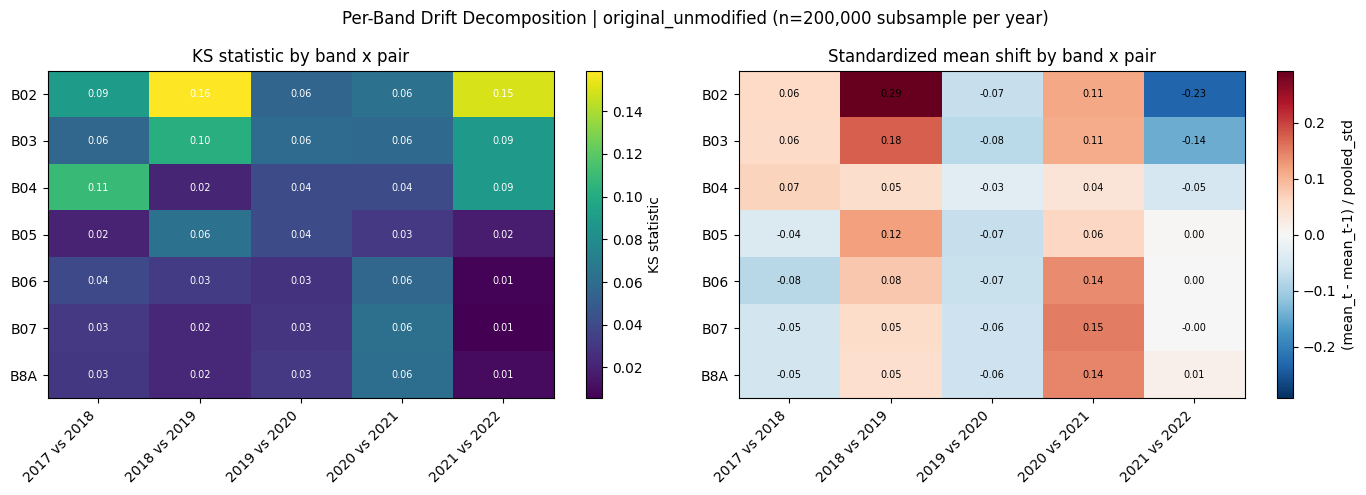

In [7]:
original_pair_df, original_band_df, original_skipped_pairs = run_distribution_test_on_dataset(
    zarr_path=original_data_path,
    method="none",
    mode="original_unmodified",
    artifact_label="original_unmodified",
    sample_fraction=SAMPLE_FRACTION,
    max_samples_per_year=MAX_SAMPLES_PER_YEAR,
)

original_reference_df = to_dist_display(original_pair_df, ["pair", "year_t_minus_1", "year_t"])
original_reference_mean_score = (
    float(original_reference_df["DriftScore"].mean()) if len(original_reference_df) > 0 else None
)

print("Original (unmodified) reference DriftScore per year pair:")
display(original_reference_df)
if original_reference_mean_score is not None:
    print(f"Mean reference DriftScore across pairs: {original_reference_mean_score:.4f}")
if SHOW_BAND_HEATMAPS and len(original_band_df) > 0:
    plot_band_heatmap(original_band_df, "original_unmodified")

## Mean/Variance Shift

Run the distribution-drift test on synthetic artifacts generated with `mean_variance_shift` for both modes.

In [8]:
print("=== Mean/Variance Shift ===")
print("Running distribution-drift test for mean_variance_shift artifacts...")

=== Mean/Variance Shift ===
Running distribution-drift test for mean_variance_shift artifacts...



### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.0, variance_scale=1.15
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.0, variance_scale=1.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.0-variance_scale1.15_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000152 (rel. p=0.4916) | MMD-L=0.000387 (rel. p=0.1527) | Energy=0.000118 (rel. p=0.3312)
  Pair time: 47.2s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000506 (rel. p=0.1826) | MMD-L=-0.000172 (rel. p=0.6857) | Energy=-0.000041 (rel. p=0.7656)
  Pair time: 49.9s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346) | Energy=-0.0

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.000152,0.000387,0.000118,0.238656
1,2018 vs 2019,2018,2019,0.000506,-0.000172,-0.000041,0.238656
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,0.853288
3,2020 vs 2021,2020,2021,-0.000180,0.000247,-0.000294,0.238656
4,2021 vs 2022,2021,2022,0.000281,0.000361,-0.000031,0.238656


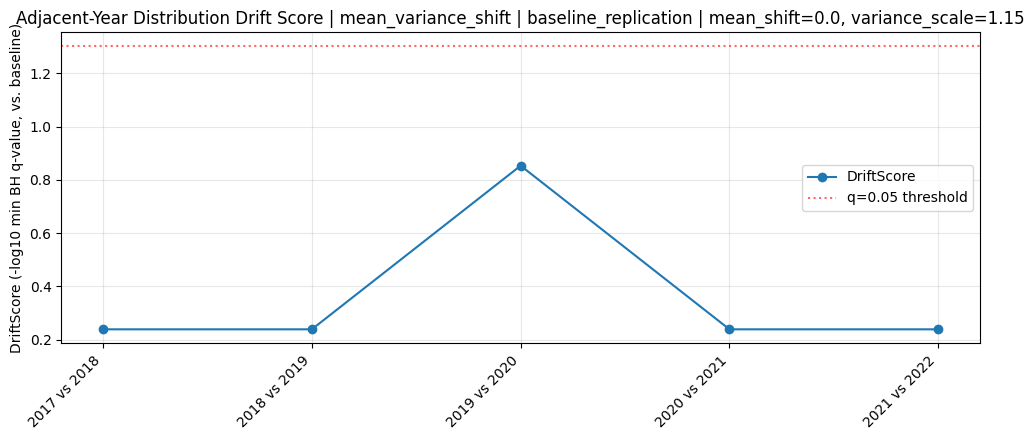

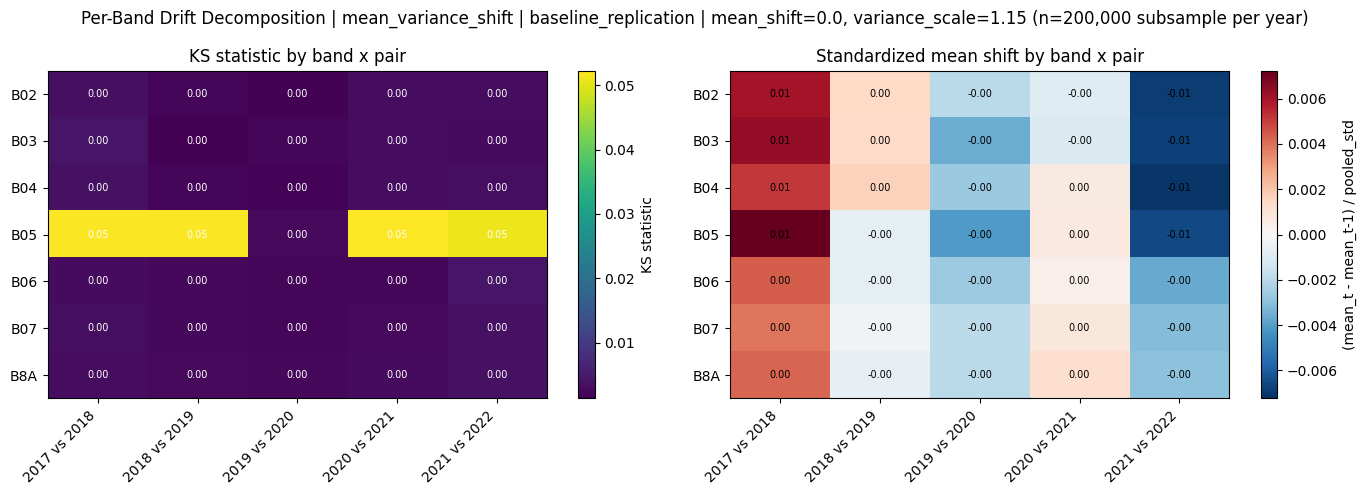


### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.0
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.0
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.0_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.002333 (rel. p=3.401e-05) | MMD-L=0.003205 (rel. p=1.11e-16) | Energy=0.000833 (rel. p=0.0001044)
  Pair time: 51.3s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.002689 (rel. p=5.902e-07) | MMD-L=0.002622 (rel. p=1.311e-11) | Energy=0.000673 (rel. p=0.005514)
  Pair time: 46.2s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346) | 

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.002333,0.003205,0.000833,14.778499
1,2018 vs 2019,2018,2019,0.002689,0.002622,0.000673,10.308276
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,1.932469
3,2020 vs 2021,2020,2021,0.002021,0.003071,0.000424,13.933400
4,2021 vs 2022,2021,2022,0.002504,0.003165,0.000686,13.933400


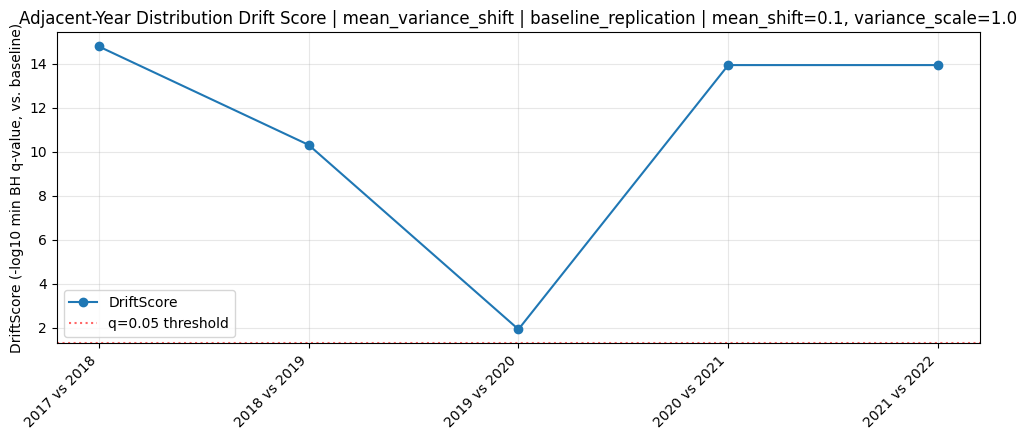

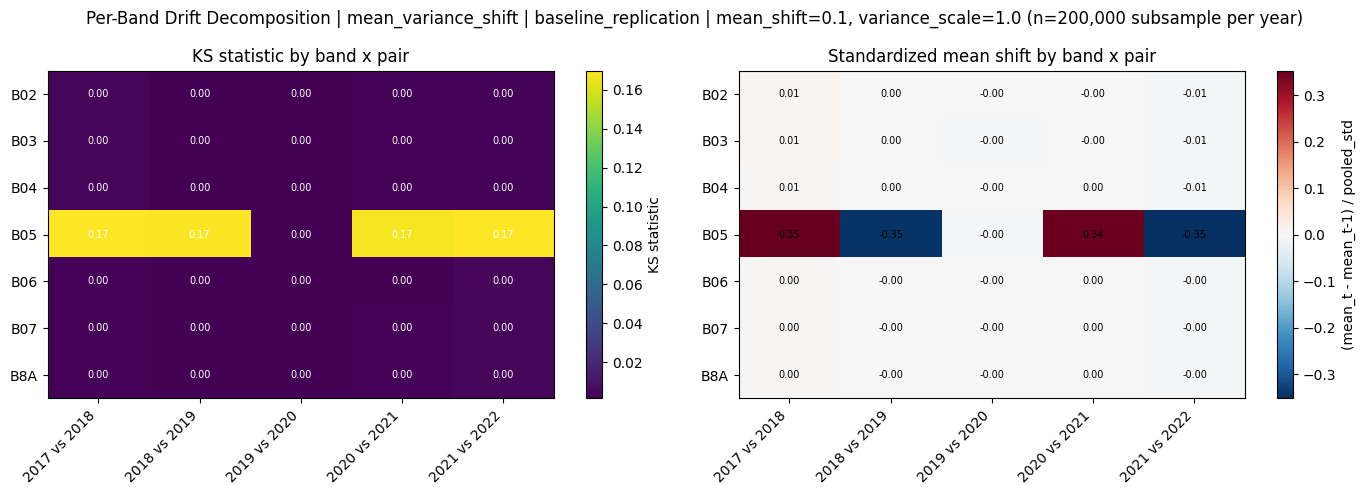


### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.15
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.15_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.002221 (rel. p=7.188e-05) | MMD-L=0.002473 (rel. p=9.289e-11) | Energy=0.000768 (rel. p=0.0003253)
  Pair time: 38.2s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.002582 (rel. p=1.347e-06) | MMD-L=0.001894 (rel. p=7.061e-07) | Energy=0.000607 (rel. p=0.01247)
  Pair time: 38.3s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346)

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.002221,0.002473,0.000768,8.855939
1,2018 vs 2019,2018,2019,0.002582,0.001894,0.000607,5.577114
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,1.894680
3,2020 vs 2021,2020,2021,0.001914,0.002337,0.000360,8.245599
4,2021 vs 2022,2021,2022,0.002392,0.002432,0.000620,8.245599


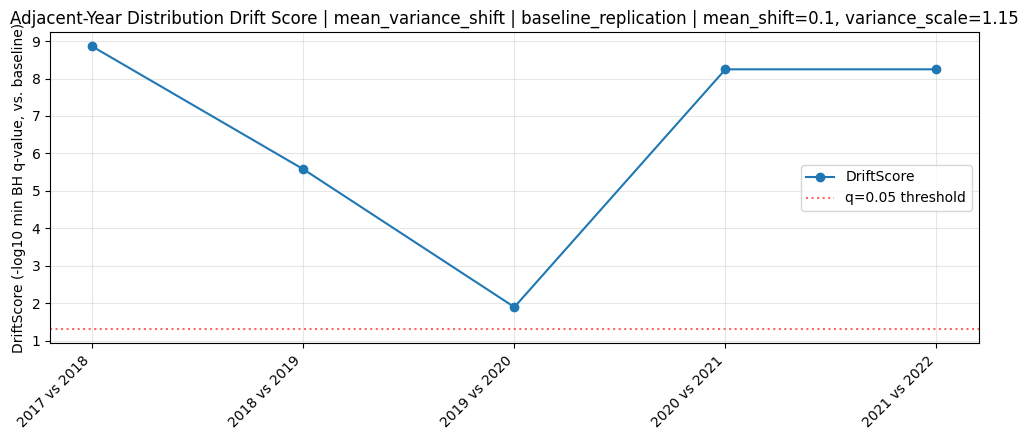

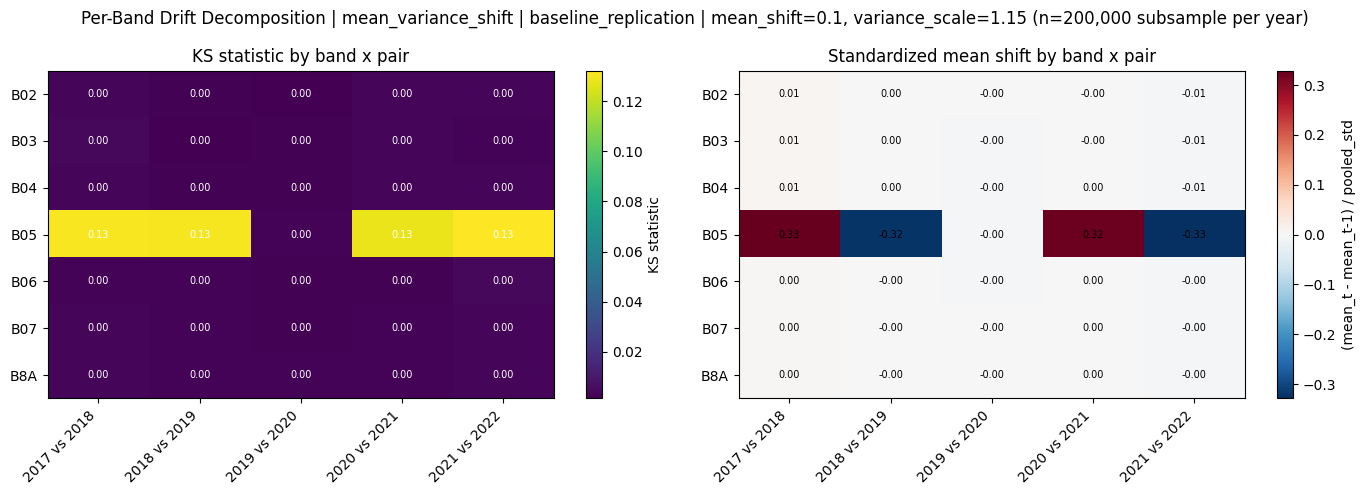


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.0, variance_scale=1.15
Artifact: mean_variance_shift | per_year_original | mean_shift=0.0, variance_scale=1.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.0-variance_scale1.15_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001422 (rel. p=0.0004577) | MMD-L=0.001813 (rel. p=1.145e-05) | Energy=0.000352 (rel. p=0.2308)
  Pair time: 39.1s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001663 (rel. p=0.0007027) | MMD-L=0.002993 (rel. p=2.22e-16) | Energy=0.000684 (rel. p=0.0007575)
  Pair time: 38.9s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03247) | MMD-L=0.000779 (rel. p=0.05105) | Energy=0.000439 (rel. p=0

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.001422,0.001813,0.000352,4.543074,6.409373
1,2018 vs 2019,2018,2019,0.001663,0.002993,0.000684,14.778499,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.707897,3.310181
3,2020 vs 2021,2020,2021,0.004546,0.002657,0.001322,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.001241,0.002113,0.000591,5.418951,8.552666


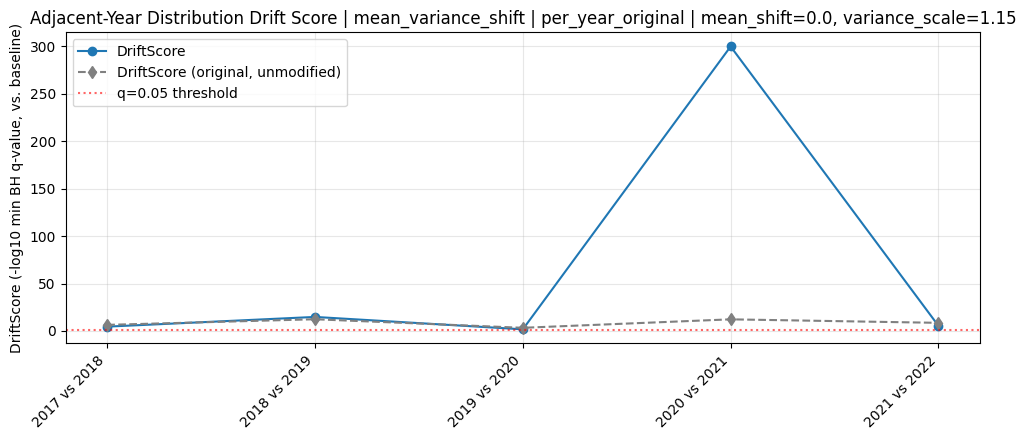

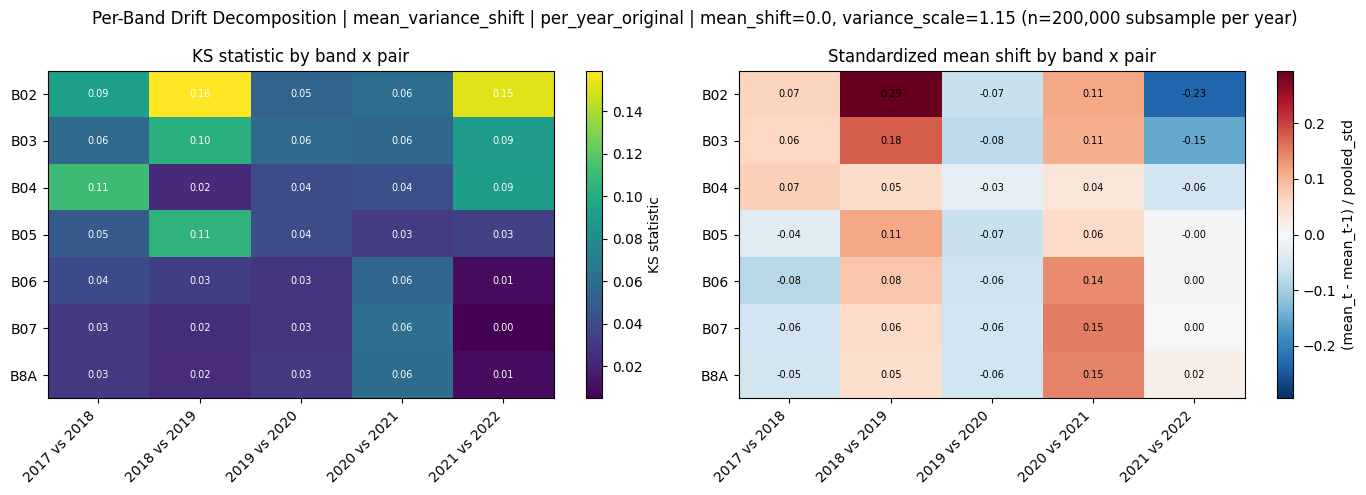


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.0
Artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.0
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.0_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.003139 (rel. p=6.64e-11) | MMD-L=0.004131 (rel. p=0) | Energy=0.000920 (rel. p=0.0005145)
  Pair time: 38.3s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.002494 (rel. p=1.403e-06) | MMD-L=0.004035 (rel. p=0) | Energy=0.001002 (rel. p=2.147e-06)
  Pair time: 36.8s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03248) | MMD-L=0.000779 (rel. p=0.05106) | Energy=0.000439 (rel. p=0.01566)
  Pair t

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.003139,0.004131,0.000920,300.000000,6.409373
1,2018 vs 2019,2018,2019,0.002494,0.004035,0.001002,300.000000,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.743065,3.310181
3,2020 vs 2021,2020,2021,0.006892,0.005896,0.002143,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.003283,0.005094,0.001300,300.000000,8.552666


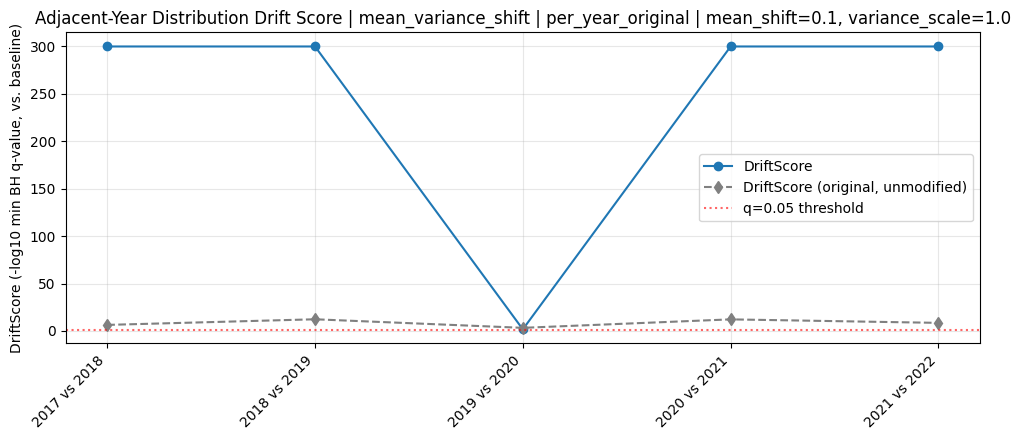

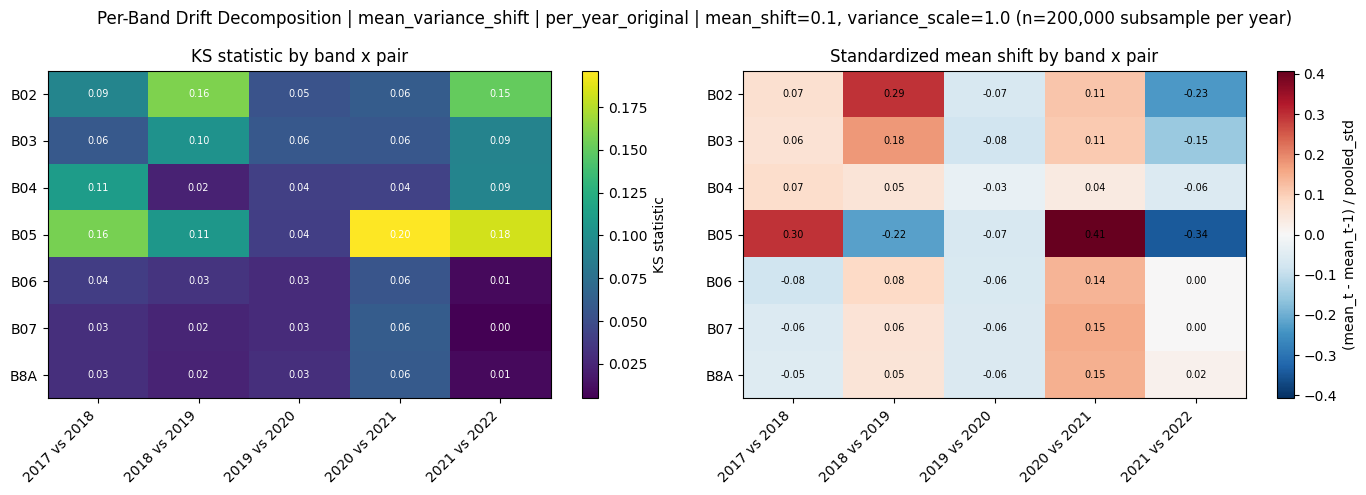


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.15
Artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.15_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.002948 (rel. p=4.995e-10) | MMD-L=0.003303 (rel. p=3.331e-16) | Energy=0.000834 (rel. p=0.001884)
  Pair time: 35.8s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.002462 (rel. p=1.71e-06) | MMD-L=0.003636 (rel. p=0) | Energy=0.000964 (rel. p=4.579e-06)
  Pair time: 35.9s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03247) | MMD-L=0.000779 (rel. p=0.05103) | Energy=0.000439 (rel. p=0.01567

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.002948,0.003303,0.000834,15.079529,6.409373
1,2018 vs 2019,2018,2019,0.002462,0.003636,0.000964,300.000000,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.742816,3.310181
3,2020 vs 2021,2020,2021,0.006771,0.005062,0.002071,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.003123,0.004170,0.001209,300.000000,8.552666


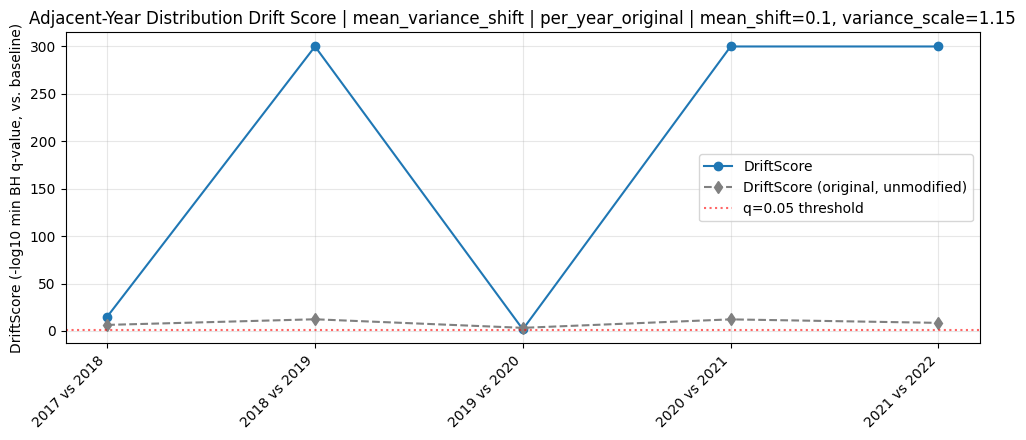

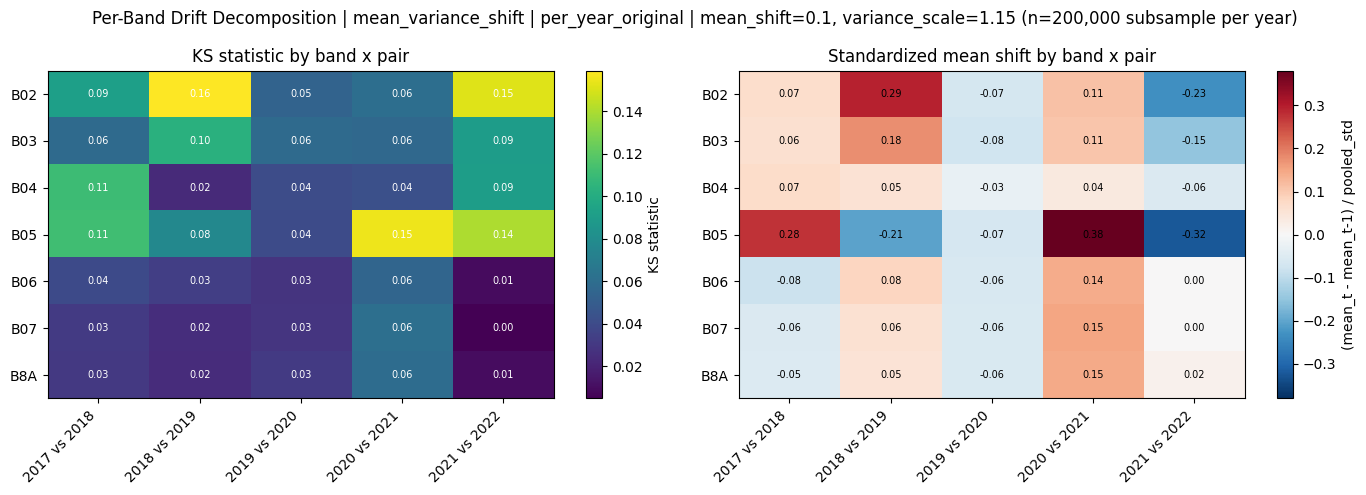

mean_variance_shift combined view:


,mode,severity_display,DriftScore,n_pairs,"DriftScore (original, unmodified)"
0,baseline_replication,"mean_shift=0.0, variance_scale=1.15",0.361582,5,NaN
1,baseline_replication,"mean_shift=0.1, variance_scale=1.0",10.977209,5,NaN
2,baseline_replication,"mean_shift=0.1, variance_scale=1.15",6.563786,5,NaN
3,per_year_original,"mean_shift=0.0, variance_scale=1.15",65.289684,5,8.569721
4,per_year_original,"mean_shift=0.1, variance_scale=1.0",240.348613,5,8.569721
5,per_year_original,"mean_shift=0.1, variance_scale=1.15",183.364469,5,8.569721


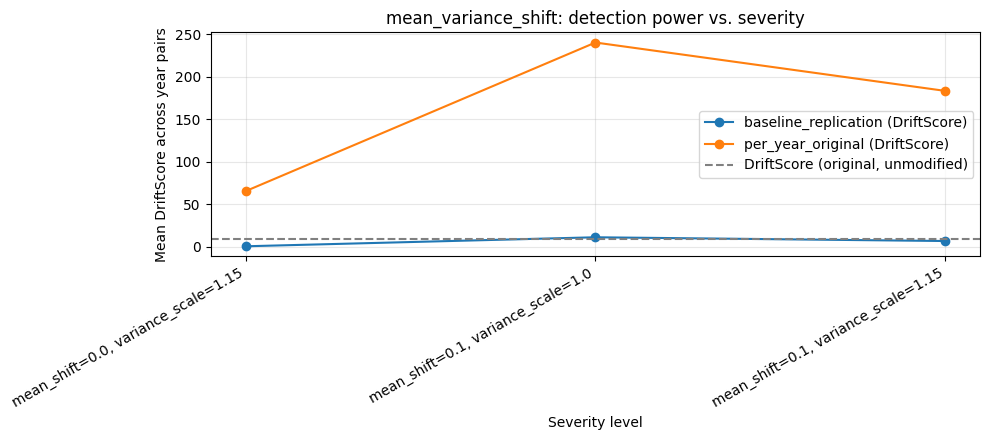

In [9]:
section_results["mean_variance_shift"] = run_method_section(
    method_name="mean_variance_shift",
    sample_fraction=SAMPLE_FRACTION,
    max_samples_per_year=MAX_SAMPLES_PER_YEAR,
 )

mean_combined = section_results["mean_variance_shift"]["combined"]
mean_summary = summarize_and_plot_section(mean_combined, "mean_variance_shift")

## Covariance Shift

Run the distribution-drift test on synthetic artifacts generated with `covariance_shift` for both modes.


### Running artifact: covariance_shift | baseline_replication | 0.05
Artifact: covariance_shift | baseline_replication | 0.05
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.05_class-1_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000104 (rel. p=0.5278) | MMD-L=0.000110 (rel. p=0.3772) | Energy=0.000092 (rel. p=0.3729)
  Pair time: 34.3s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000450 (rel. p=0.213) | MMD-L=-0.000448 (rel. p=0.8839) | Energy=-0.000065 (rel. p=0.7985)
  Pair time: 34.2s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346) | Energy=-0.000134 (rel. p=0.6801)
  Pair time: 34.9s

[4/5] 2020 vs 2021
  Using n_prev=5,590,800, n_cur

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.000104,0.000110,0.000092,0.070512
1,2018 vs 2019,2018,2019,0.000450,-0.000448,-0.000065,0.070512
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,0.853288
3,2020 vs 2021,2020,2021,-0.000238,-0.000029,-0.000321,0.070512
4,2021 vs 2022,2021,2022,0.000225,0.000089,-0.000056,0.070512


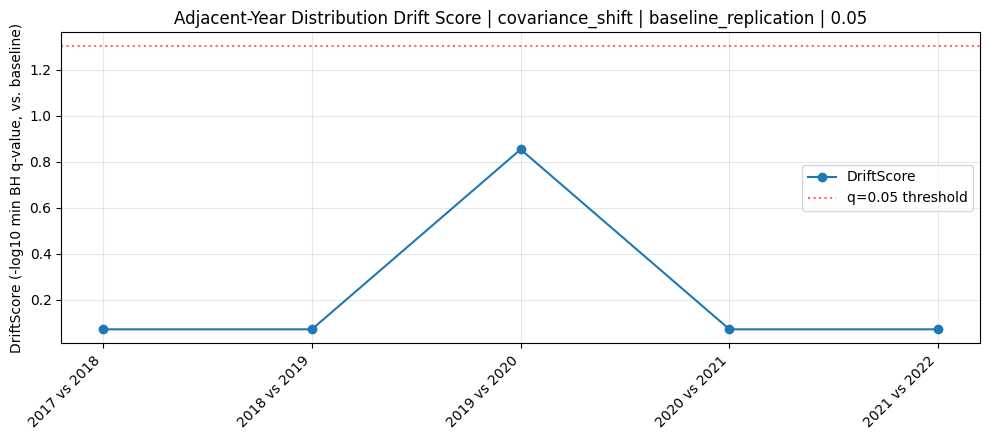

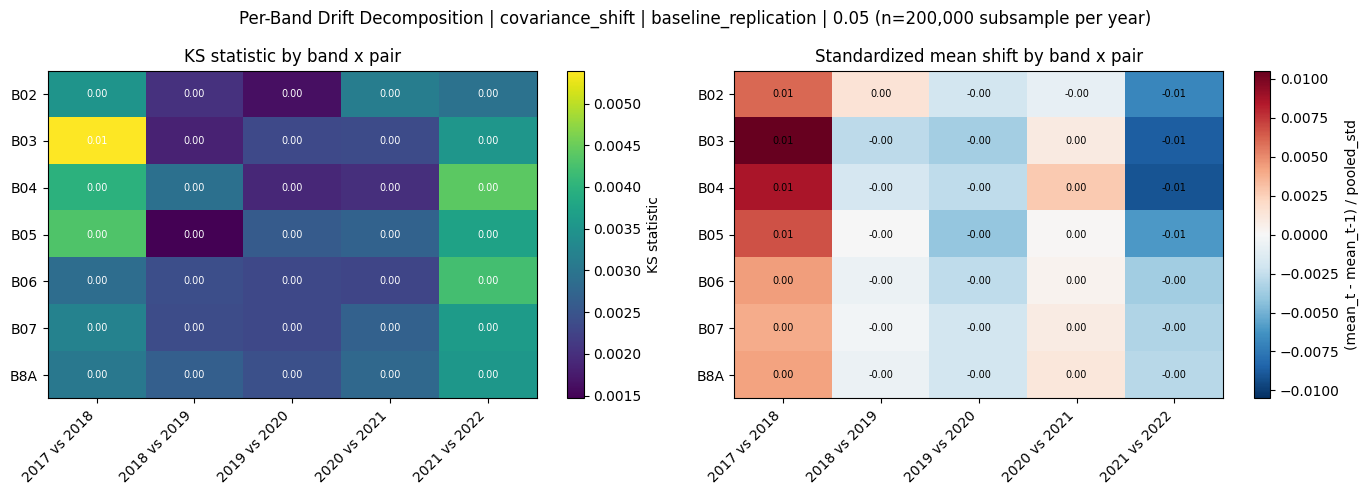


### Running artifact: covariance_shift | baseline_replication | 0.15
Artifact: covariance_shift | baseline_replication | 0.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.15_class-1_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000107 (rel. p=0.5252) | MMD-L=0.000115 (rel. p=0.3733) | Energy=0.000094 (rel. p=0.3696)
  Pair time: 34.2s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000451 (rel. p=0.2114) | MMD-L=-0.000443 (rel. p=0.8814) | Energy=-0.000063 (rel. p=0.7972)
  Pair time: 34.0s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346) | Energy=-0.000134 (rel. p=0.6801)
  Pair time: 34.5s

[4/5] 2020 vs 2021
  Using n_prev=5,590,800, n_cu

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.000107,0.000115,0.000094,0.070512
1,2018 vs 2019,2018,2019,0.000451,-0.000443,-0.000063,0.070512
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,0.853288
3,2020 vs 2021,2020,2021,-0.000237,-0.000029,-0.000321,0.070512
4,2021 vs 2022,2021,2022,0.000225,0.000091,-0.000056,0.070512


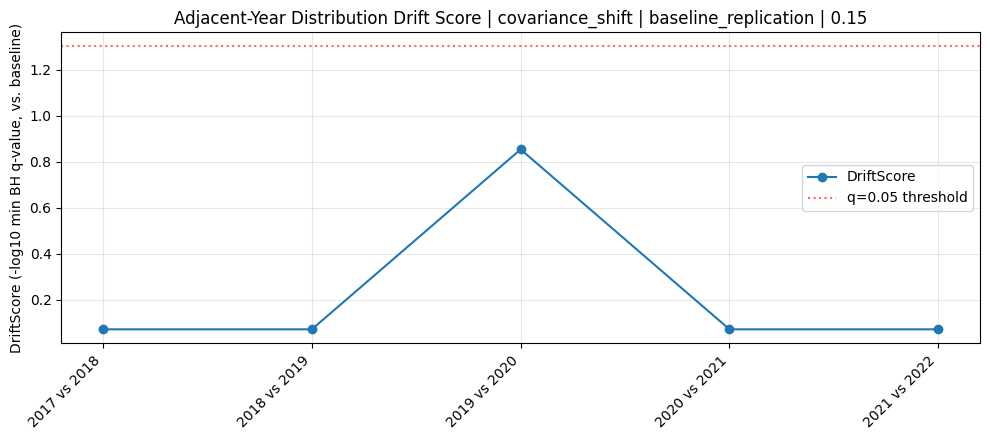

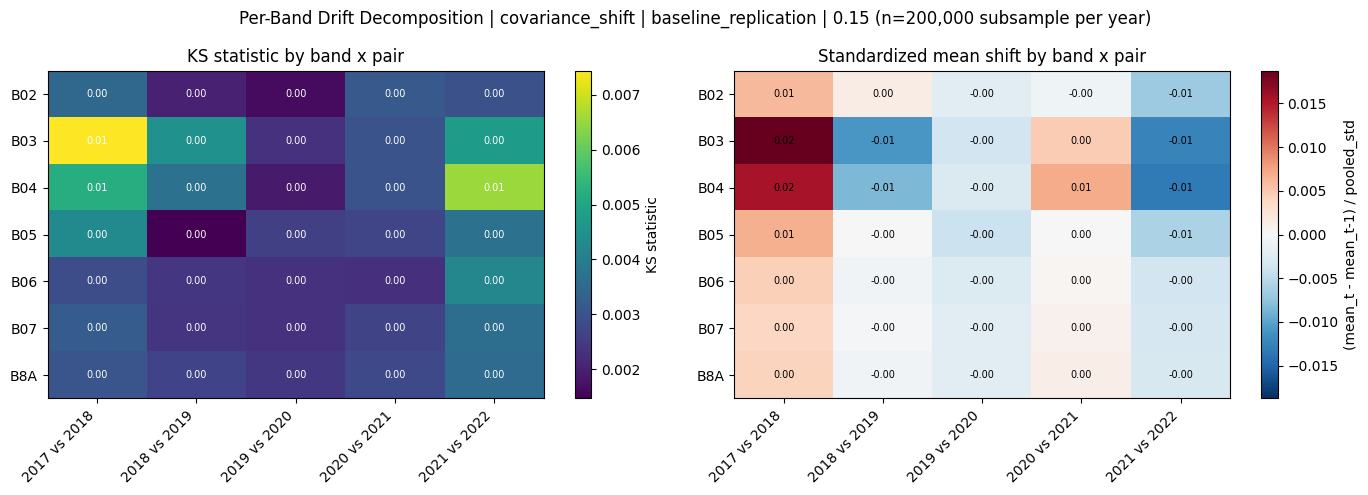


### Running artifact: covariance_shift | baseline_replication | 0.3
Artifact: covariance_shift | baseline_replication | 0.3
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.3_class-1_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000114 (rel. p=0.5186) | MMD-L=0.000124 (rel. p=0.367) | Energy=0.000098 (rel. p=0.3627)
  Pair time: 35.4s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000457 (rel. p=0.2072) | MMD-L=-0.000433 (rel. p=0.8762) | Energy=-0.000058 (rel. p=0.7937)
  Pair time: 42.7s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346) | Energy=-0.000134 (rel. p=0.6801)
  Pair time: 39.4s

[4/5] 2020 vs 2021
  Using n_prev=5,590,800, n_curr=5

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.000114,0.000124,0.000098,0.070512
1,2018 vs 2019,2018,2019,0.000457,-0.000433,-0.000058,0.070512
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,0.853288
3,2020 vs 2021,2020,2021,-0.000234,-0.000026,-0.000321,0.070512
4,2021 vs 2022,2021,2022,0.000225,0.000096,-0.000056,0.070512


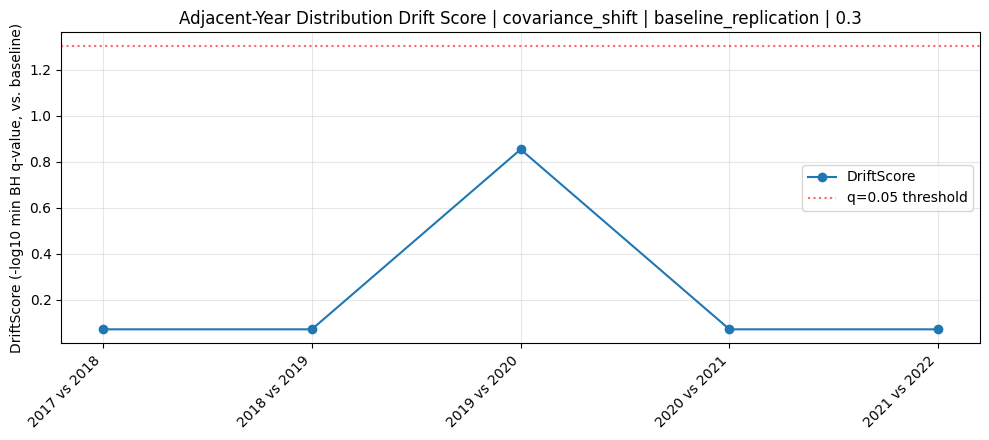

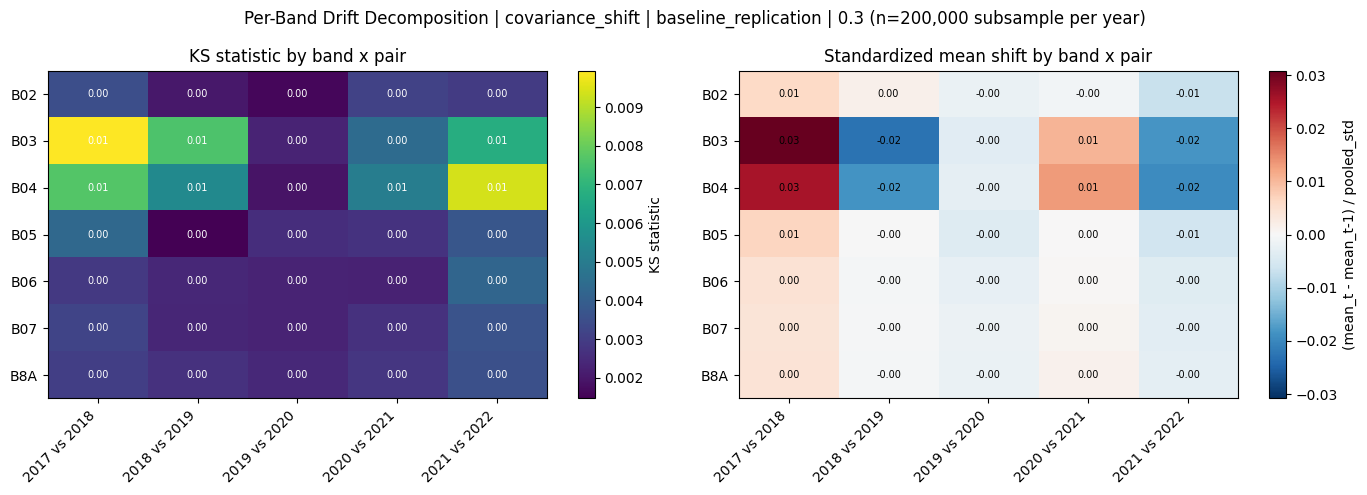


### Running artifact: covariance_shift | per_year_original | 0.05
Artifact: covariance_shift | per_year_original | 0.05
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.05_class-1_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001481 (rel. p=0.0003325) | MMD-L=0.001772 (rel. p=1.917e-05) | Energy=0.000360 (rel. p=0.2197)
  Pair time: 40.1s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001562 (rel. p=0.001343) | MMD-L=0.002548 (rel. p=1.815e-12) | Energy=0.000644 (rel. p=0.001416)
  Pair time: 34.4s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03247) | MMD-L=0.000779 (rel. p=0.0511) | Energy=0.000439 (rel. p=0.01567)
  Pair time: 34.0s

[4/5] 2020 vs 2021
  Using n_prev=5,596,320, n_curr=5,596,320
  R

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.001481,0.001772,0.000360,4.319384,6.409373
1,2018 vs 2019,2018,2019,0.001562,0.002548,0.000644,10.866011,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.708081,3.310181
3,2020 vs 2021,2020,2021,0.004476,0.002493,0.001295,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.001255,0.002115,0.000595,5.374651,8.552666


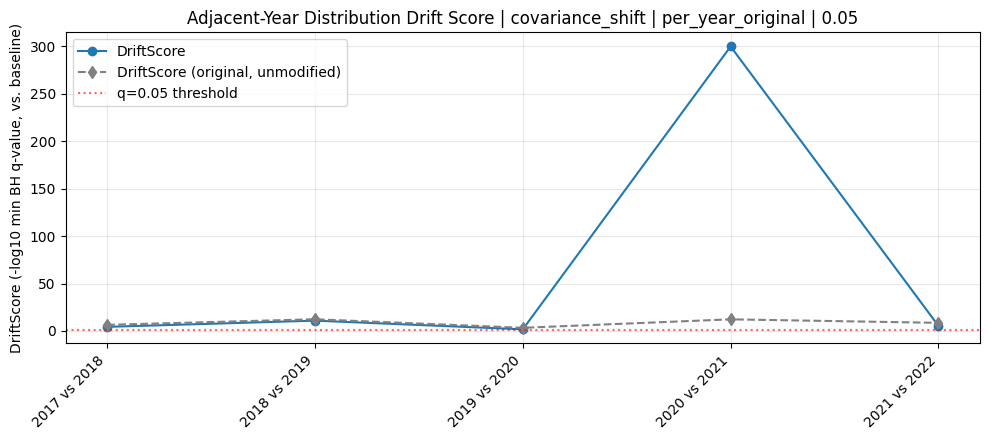

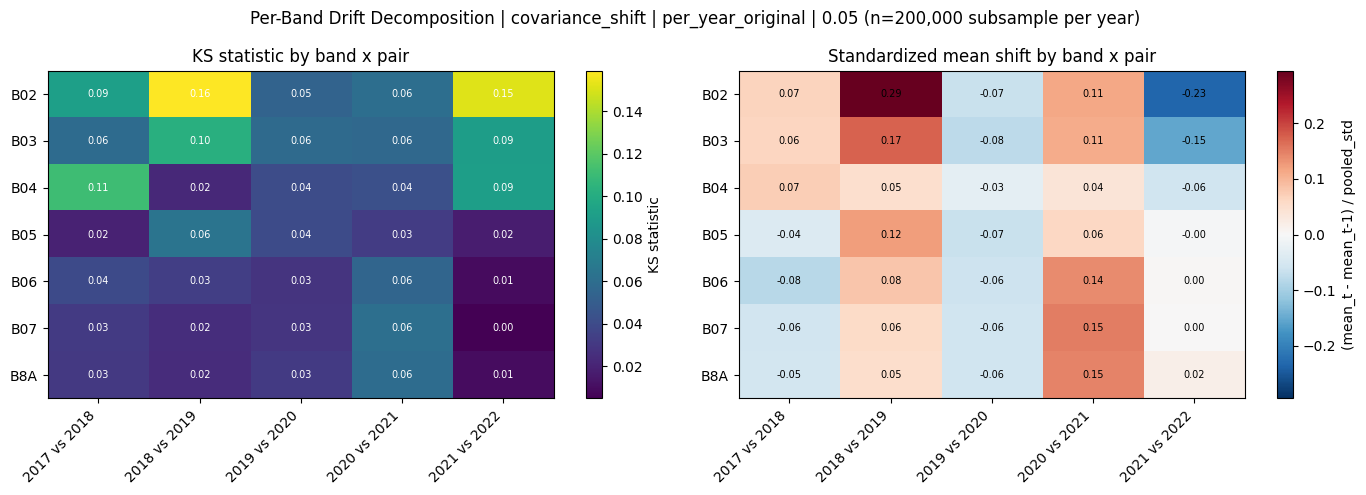


### Running artifact: covariance_shift | per_year_original | 0.15
Artifact: covariance_shift | per_year_original | 0.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.15_class-1_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001484 (rel. p=0.0003262) | MMD-L=0.001758 (rel. p=2.172e-05) | Energy=0.000361 (rel. p=0.2185)
  Pair time: 35.6s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001536 (rel. p=0.001546) | MMD-L=0.002526 (rel. p=2.734e-12) | Energy=0.000636 (rel. p=0.001579)
  Pair time: 34.1s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03248) | MMD-L=0.000779 (rel. p=0.0511) | Energy=0.000439 (rel. p=0.01567)
  Pair time: 32.9s

[4/5] 2020 vs 2021
  Using n_prev=5,596,320, n_curr=5,596,320
  R

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.001484,0.001758,0.000361,4.265235,6.409373
1,2018 vs 2019,2018,2019,0.001536,0.002526,0.000636,10.688135,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.708048,3.310181
3,2020 vs 2021,2020,2021,0.004496,0.002506,0.001299,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.001264,0.002119,0.000599,5.400689,8.552666


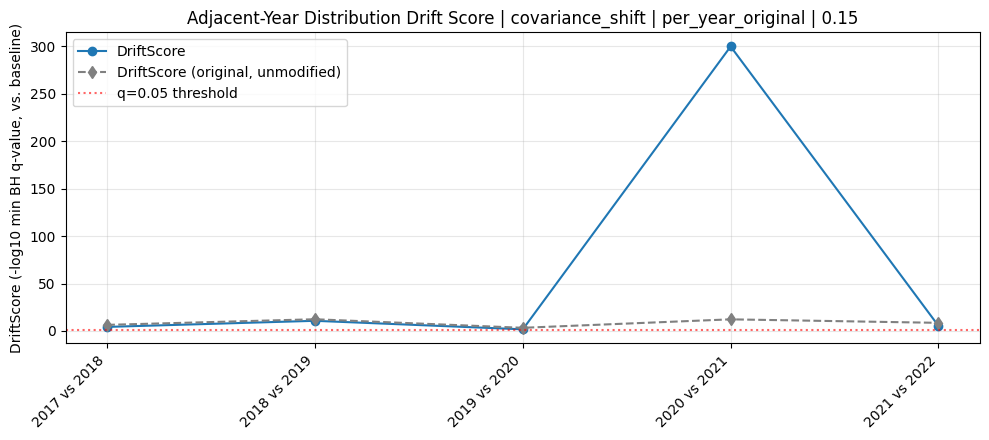

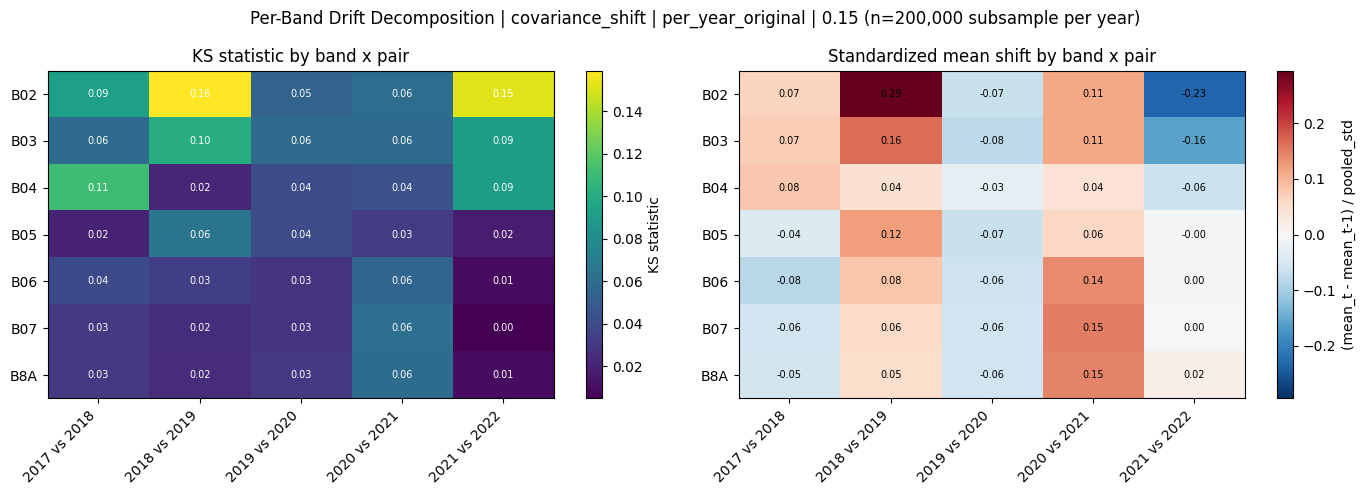


### Running artifact: covariance_shift | per_year_original | 0.3
Artifact: covariance_shift | per_year_original | 0.3
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.3_class-1_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001486 (rel. p=0.0003197) | MMD-L=0.001735 (rel. p=2.666e-05) | Energy=0.000362 (rel. p=0.2169)
  Pair time: 31.8s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001503 (rel. p=0.001852) | MMD-L=0.002507 (rel. p=3.725e-12) | Energy=0.000627 (rel. p=0.001816)
  Pair time: 32.7s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03249) | MMD-L=0.000779 (rel. p=0.0511) | Energy=0.000439 (rel. p=0.01567)
  Pair time: 31.7s

[4/5] 2020 vs 2021
  Using n_prev=5,596,320, n_curr=5,596,320
  RESU

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.001486,0.001735,0.000362,4.176124,6.409373
1,2018 vs 2019,2018,2019,0.001503,0.002507,0.000627,10.647254,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.707997,3.310181
3,2020 vs 2021,2020,2021,0.004530,0.002523,0.001307,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.001275,0.002117,0.000604,5.399880,8.552666


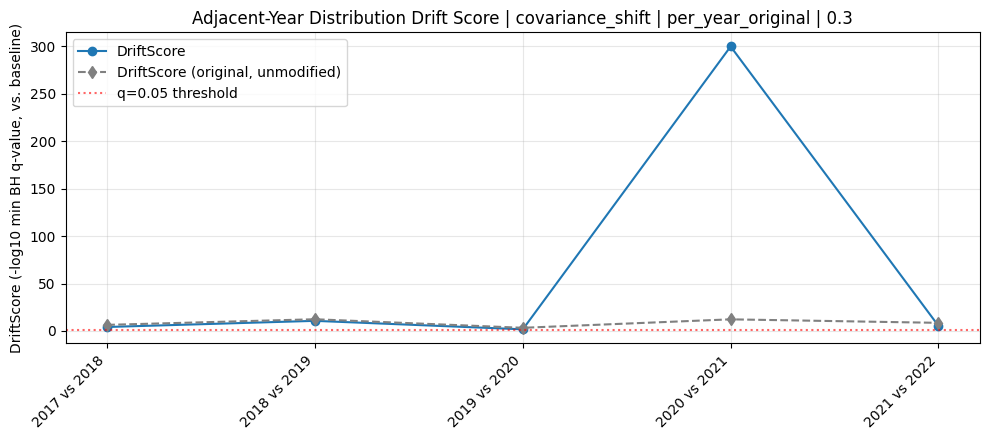

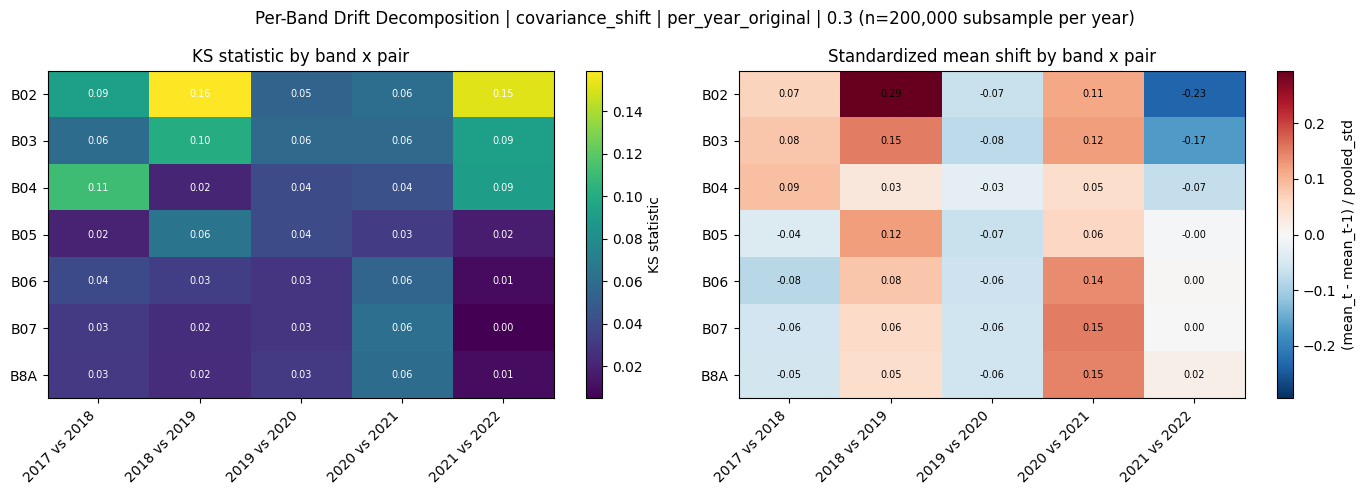

covariance_shift combined view:


,mode,severity_display,DriftScore,n_pairs,"DriftScore (original, unmodified)"
0,baseline_replication,0.05,0.227067,5,NaN
1,baseline_replication,0.15,0.227067,5,NaN
2,baseline_replication,0.3,0.227067,5,NaN
3,per_year_original,0.05,64.453625,5,8.569721
4,per_year_original,0.15,64.412421,5,8.569721
5,per_year_original,0.3,64.386251,5,8.569721


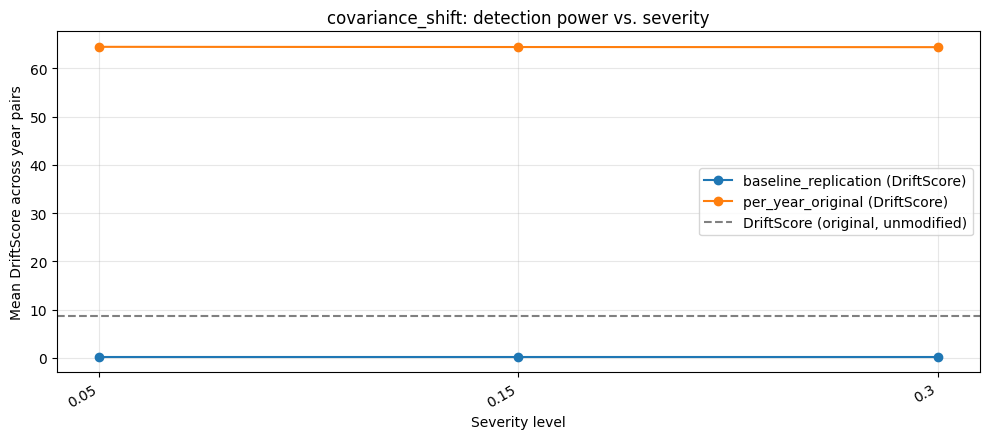

In [10]:
section_results["covariance_shift"] = run_method_section(
    method_name="covariance_shift",
    sample_fraction=SAMPLE_FRACTION,
    max_samples_per_year=MAX_SAMPLES_PER_YEAR,
 )

cov_combined = section_results["covariance_shift"]["combined"]
cov_summary = summarize_and_plot_section(cov_combined, "covariance_shift")

## Noise Injection

Run the distribution-drift test on synthetic artifacts generated with `noise_injection` for both modes.


### Running artifact: noise_injection | baseline_replication | 0.04
Artifact: noise_injection | baseline_replication | 0.04
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.04_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000107 (rel. p=0.5228) | MMD-L=0.000120 (rel. p=0.3721) | Energy=0.000095 (rel. p=0.3699)
  Pair time: 30.9s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000437 (rel. p=0.2231) | MMD-L=-0.000444 (rel. p=0.8848) | Energy=-0.000063 (rel. p=0.7942)
  Pair time: 32.5s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346) | Energy=-0.000134 (rel. p=0.6801)
  Pair time: 32.0s

[4/5] 2020 vs 2021
  Using n_prev=5,590,800, n_curr=5,590,80

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.000107,0.000120,0.000095,0.068459
1,2018 vs 2019,2018,2019,0.000437,-0.000444,-0.000063,0.068459
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,0.853288
3,2020 vs 2021,2020,2021,-0.000256,-0.000021,-0.000322,0.068459
4,2021 vs 2022,2021,2022,0.000233,0.000091,-0.000060,0.068459


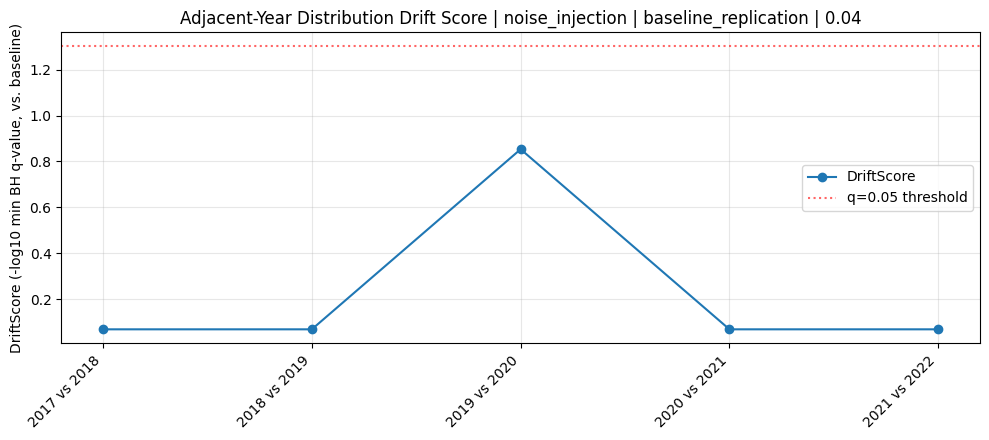

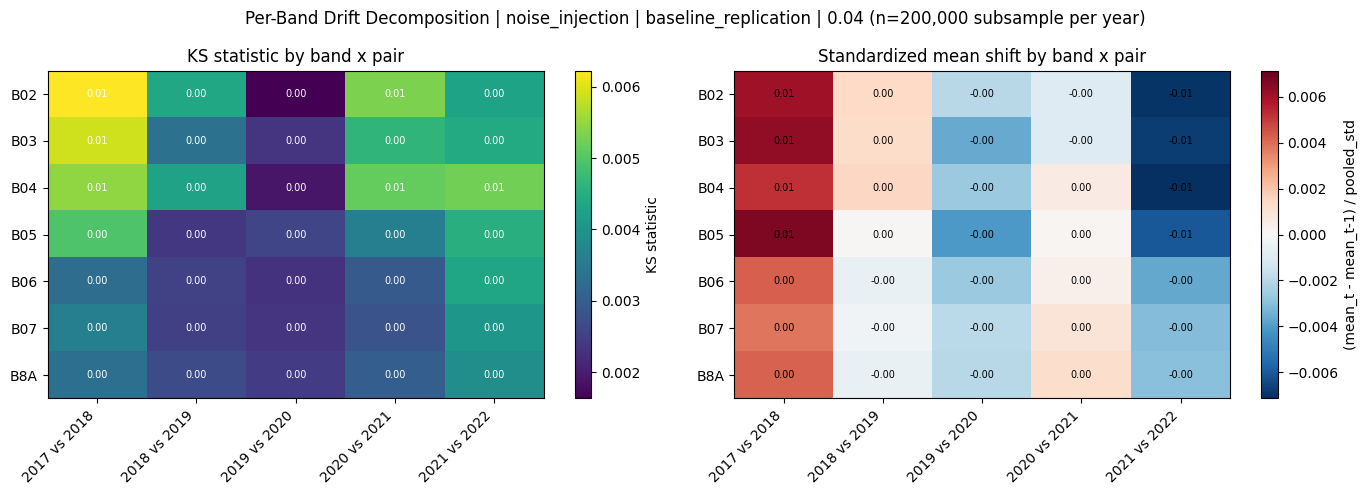


### Running artifact: noise_injection | baseline_replication | 0.08
Artifact: noise_injection | baseline_replication | 0.08
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.08_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000113 (rel. p=0.516) | MMD-L=0.000147 (rel. p=0.3507) | Energy=0.000107 (rel. p=0.3516)
  Pair time: 31.5s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000427 (rel. p=0.2315) | MMD-L=-0.000426 (rel. p=0.8783) | Energy=-0.000052 (rel. p=0.7776)
  Pair time: 31.1s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346) | Energy=-0.000134 (rel. p=0.6801)
  Pair time: 30.2s

[4/5] 2020 vs 2021
  Using n_prev=5,590,800, n_curr=5,590,800

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.000113,0.000147,0.000107,0.065469
1,2018 vs 2019,2018,2019,0.000427,-0.000426,-0.000052,0.065469
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,0.853288
3,2020 vs 2021,2020,2021,-0.000268,-0.000006,-0.000314,0.065469
4,2021 vs 2022,2021,2022,0.000244,0.000108,-0.000056,0.065469


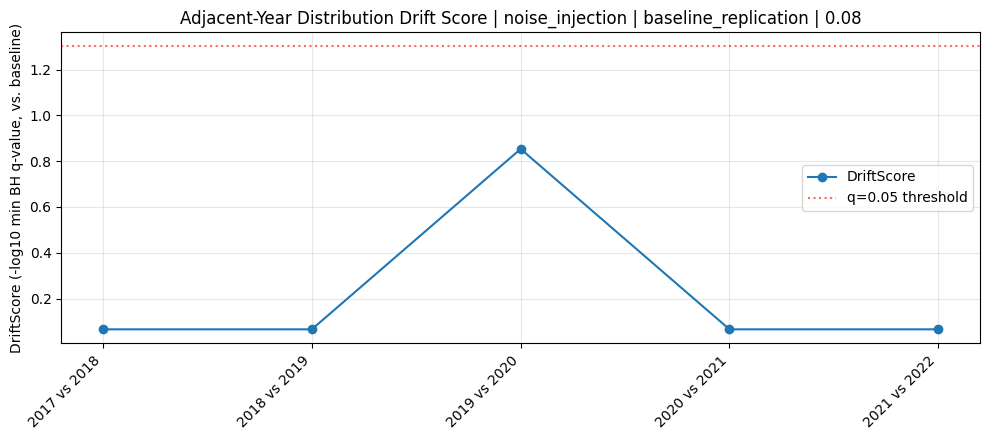

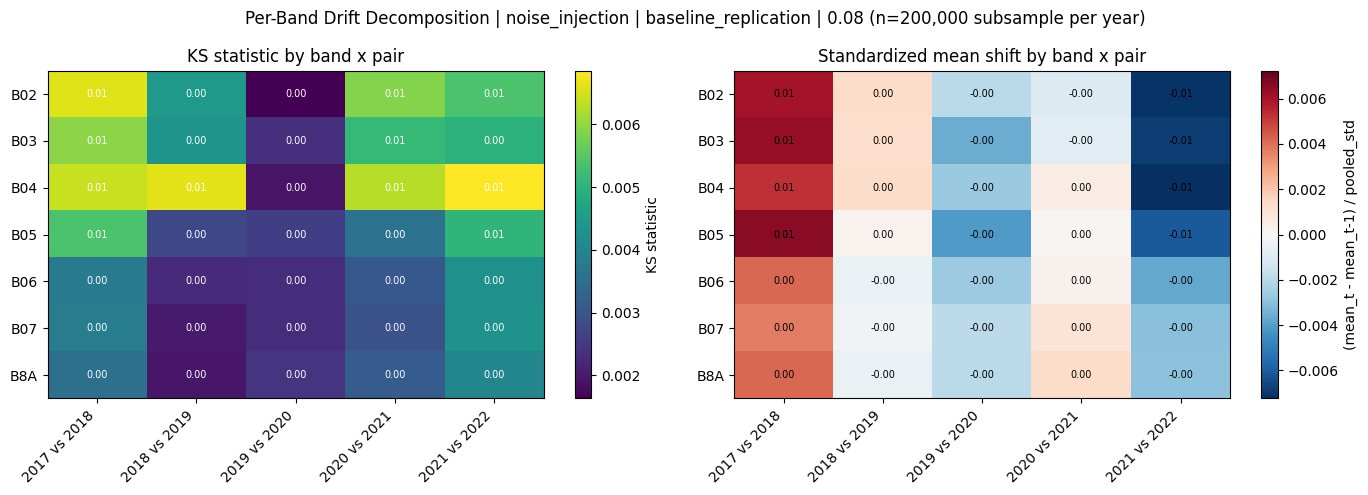


### Running artifact: noise_injection | baseline_replication | 0.16
Artifact: noise_injection | baseline_replication | 0.16
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.16_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000166 (rel. p=0.4714) | MMD-L=0.000321 (rel. p=0.2105) | Energy=0.000198 (rel. p=0.2155)
  Pair time: 38.3s

[2/5] 2018 vs 2019
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000450 (rel. p=0.2216) | MMD-L=-0.000246 (rel. p=0.7663) | Energy=0.000037 (rel. p=0.6343)
  Pair time: 48.9s

[3/5] 2019 vs 2020
  Using n_prev=5,590,800, n_curr=5,590,800
  RESULTS: MMD-G=0.000406 (rel. p=0.1551) | MMD-L=0.000650 (rel. p=0.009346) | Energy=-0.000134 (rel. p=0.6801)
  Pair time: 48.4s

[4/5] 2020 vs 2021
  Using n_prev=5,590,800, n_curr=5,590,800

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,2017 vs 2018,2017,2018,0.000166,0.000321,0.000198,0.245717
1,2018 vs 2019,2018,2019,0.000450,-0.000246,0.000037,0.245717
2,2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,0.853288
3,2020 vs 2021,2020,2021,-0.000239,0.000145,-0.000231,0.202036
4,2021 vs 2022,2021,2022,0.000314,0.000262,0.000018,0.245717


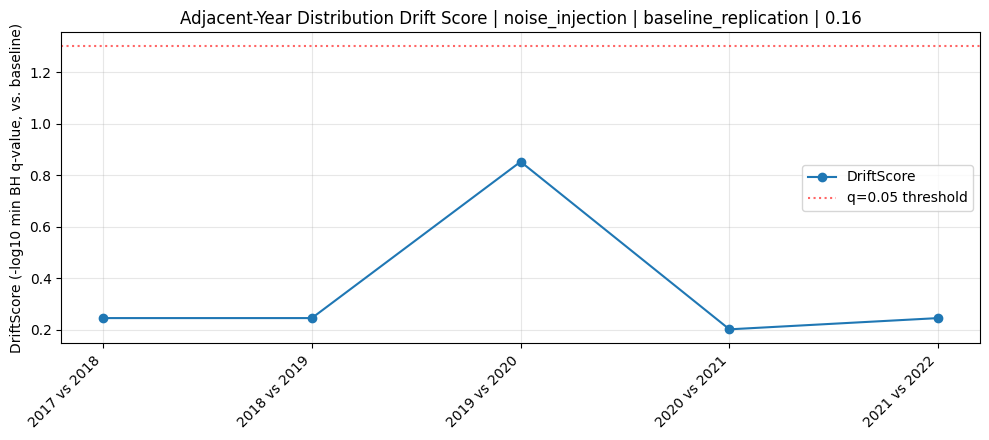

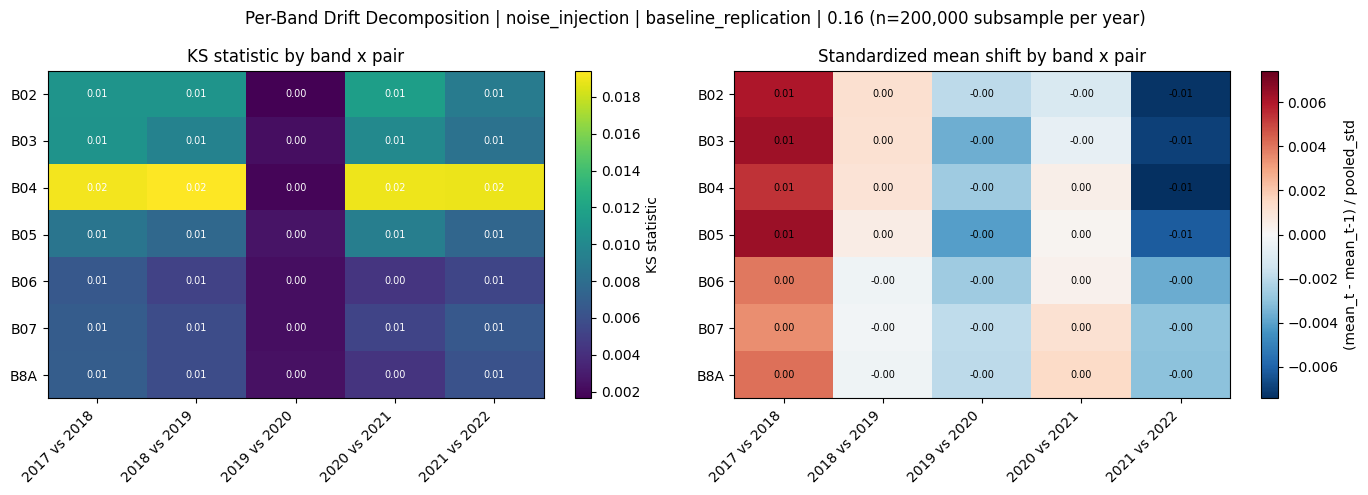


### Running artifact: noise_injection | per_year_original | 0.04
Artifact: noise_injection | per_year_original | 0.04
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-noise_injection_severity-0.04_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001452 (rel. p=0.0003917) | MMD-L=0.001747 (rel. p=2.62e-05) | Energy=0.000354 (rel. p=0.2316)
  Pair time: 40.5s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001559 (rel. p=0.001317) | MMD-L=0.002550 (rel. p=1.785e-12) | Energy=0.000650 (rel. p=0.001372)
  Pair time: 48.9s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03247) | MMD-L=0.000779 (rel. p=0.05113) | Energy=0.000439 (rel. p=0.01567)
  Pair time: 48.2s

[4/5] 2020 vs 2021
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.001452,0.001747,0.000354,4.183825,6.409373
1,2018 vs 2019,2018,2019,0.001559,0.002550,0.000650,10.873188,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.708077,3.310181
3,2020 vs 2021,2020,2021,0.004489,0.002501,0.001299,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.001247,0.002109,0.000590,5.342203,8.552666


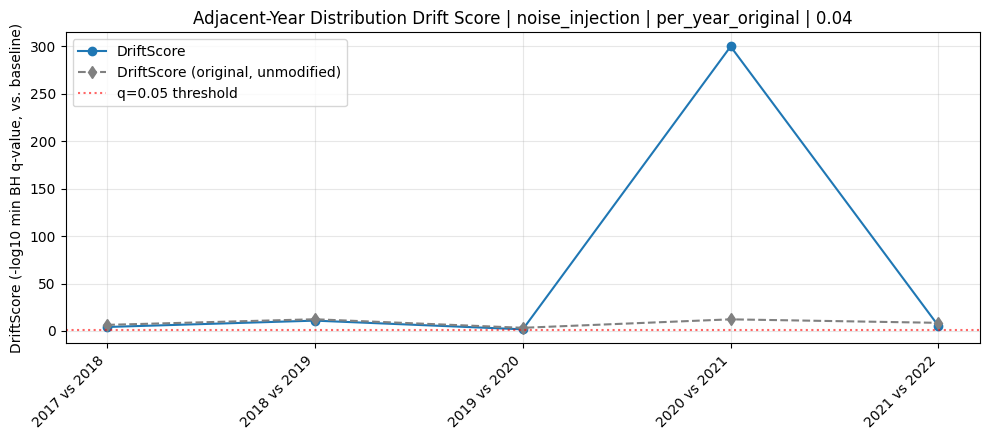

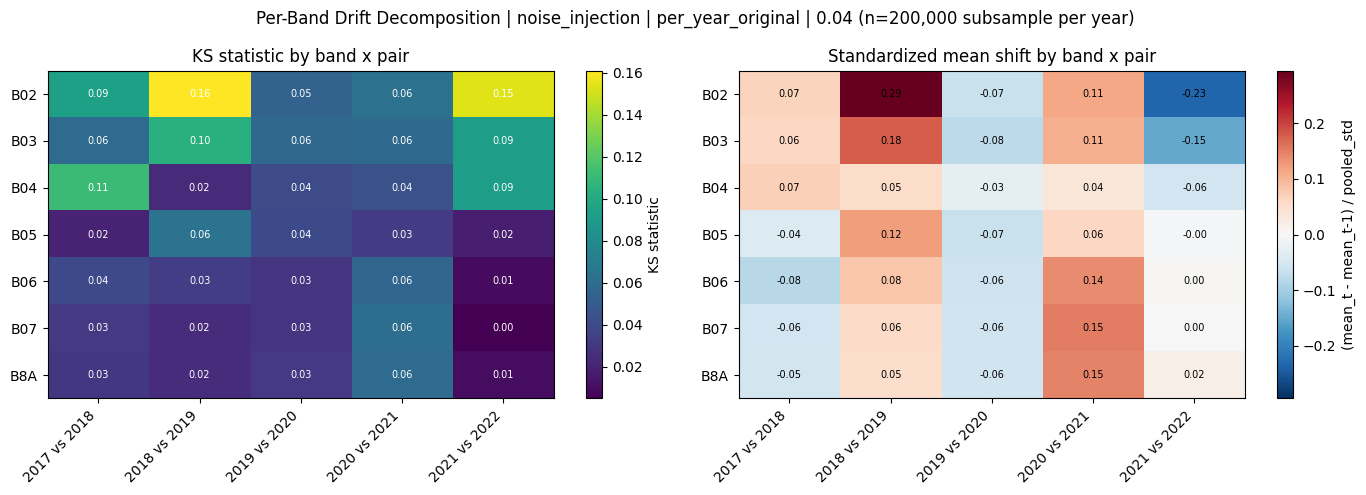


### Running artifact: noise_injection | per_year_original | 0.08
Artifact: noise_injection | per_year_original | 0.08
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-noise_injection_severity-0.08_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001398 (rel. p=0.0005349) | MMD-L=0.001684 (rel. p=5.07e-05) | Energy=0.000344 (rel. p=0.2484)
  Pair time: 35.4s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001526 (rel. p=0.001512) | MMD-L=0.002524 (rel. p=2.504e-12) | Energy=0.000653 (rel. p=0.001355)
  Pair time: 34.3s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03246) | MMD-L=0.000779 (rel. p=0.05116) | Energy=0.000439 (rel. p=0.01567)
  Pair time: 32.2s

[4/5] 2020 vs 2021
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.001398,0.001684,0.000344,3.897076,6.409373
1,2018 vs 2019,2018,2019,0.001526,0.002524,0.000653,10.902338,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.708058,3.310181
3,2020 vs 2021,2020,2021,0.004538,0.002544,0.001322,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.001235,0.002104,0.000590,5.379351,8.552666


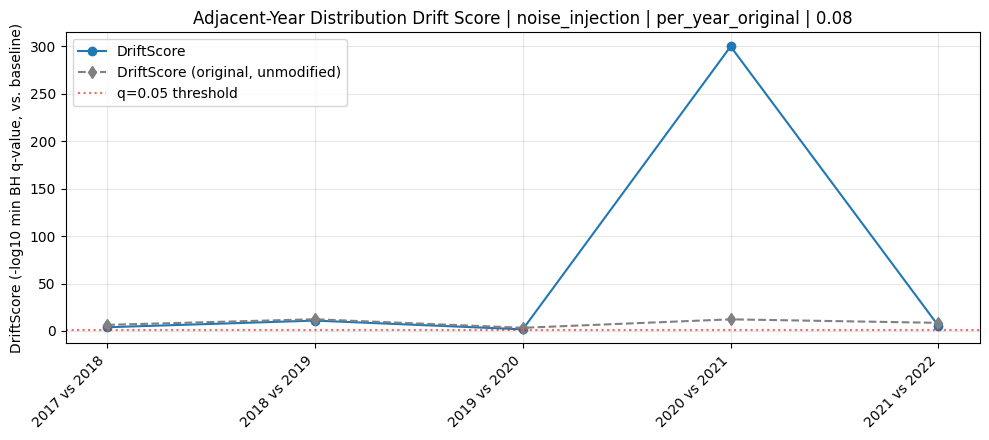

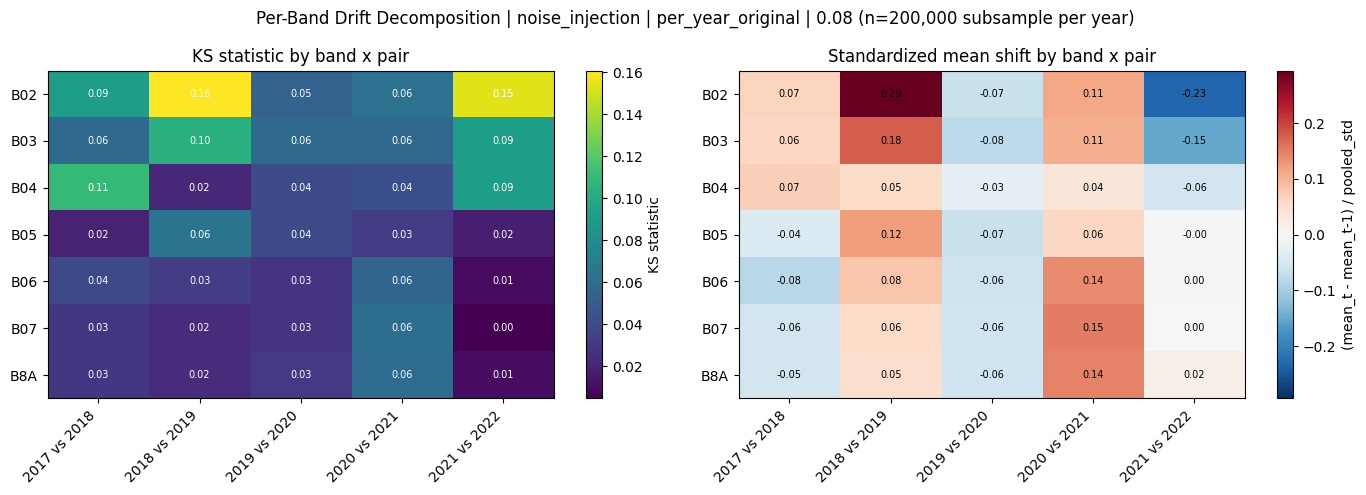


### Running artifact: noise_injection | per_year_original | 0.16
Artifact: noise_injection | per_year_original | 0.16
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-noise_injection_severity-0.16_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001251 (rel. p=0.00122) | MMD-L=0.001542 (rel. p=0.0001823) | Energy=0.000360 (rel. p=0.2284)
  Pair time: 41.3s

[2/5] 2018 vs 2019
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.001455 (rel. p=0.002011) | MMD-L=0.002531 (rel. p=1.148e-12) | Energy=0.000711 (rel. p=0.0005794)
  Pair time: 41.0s

[3/5] 2019 vs 2020
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD-G=0.000999 (rel. p=0.03245) | MMD-L=0.000779 (rel. p=0.05119) | Energy=0.000439 (rel. p=0.01567)
  Pair time: 38.3s

[4/5] 2020 vs 2021
  Using n_prev=5,596,320, n_curr=5,596,320
  RESULTS: MMD

,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore,"DriftScore (original, unmodified)"
0,2017 vs 2018,2017,2018,0.001251,0.001542,0.000360,3.341293,6.409373
1,2018 vs 2019,2018,2019,0.001455,0.002531,0.000711,11.241183,12.337589
2,2019 vs 2020,2019,2020,0.000999,0.000779,0.000439,1.708029,3.310181
3,2020 vs 2021,2020,2021,0.004758,0.002819,0.001457,300.000000,12.238795
4,2021 vs 2022,2021,2022,0.001224,0.002148,0.000646,5.854745,8.552666


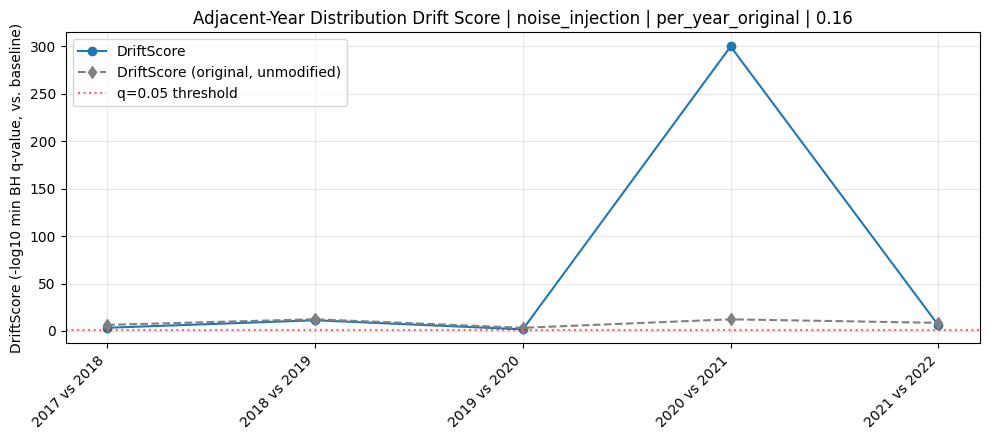

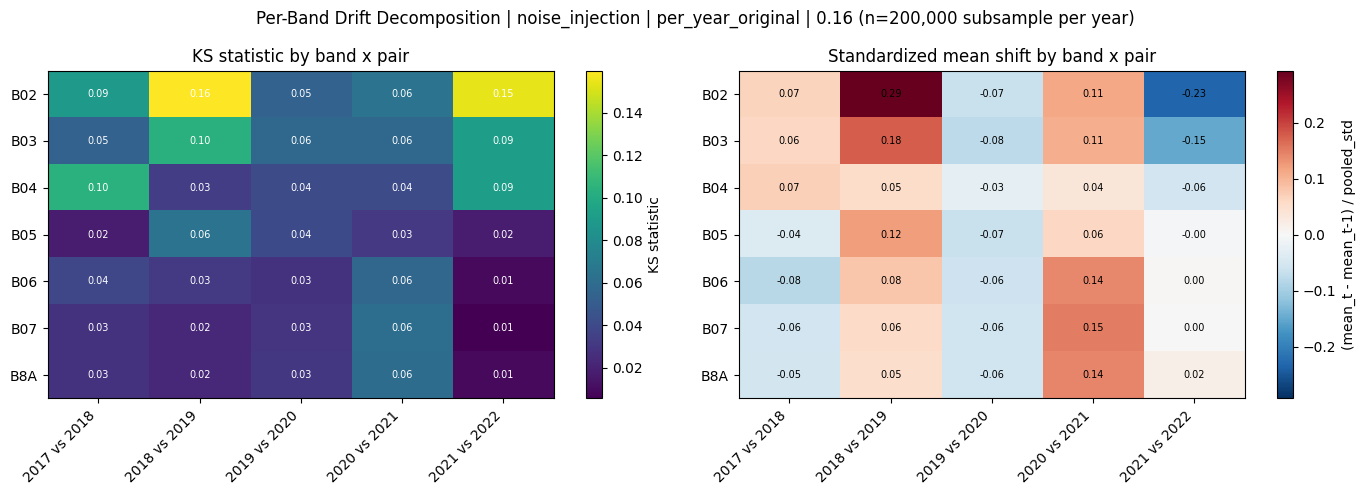

noise_injection combined view:


,mode,severity_display,DriftScore,n_pairs,"DriftScore (original, unmodified)"
0,baseline_replication,0.04,0.225425,5,NaN
1,baseline_replication,0.08,0.223032,5,NaN
2,baseline_replication,0.16,0.358495,5,NaN
3,per_year_original,0.04,64.421459,5,8.569721
4,per_year_original,0.08,64.377365,5,8.569721
5,per_year_original,0.16,64.429050,5,8.569721


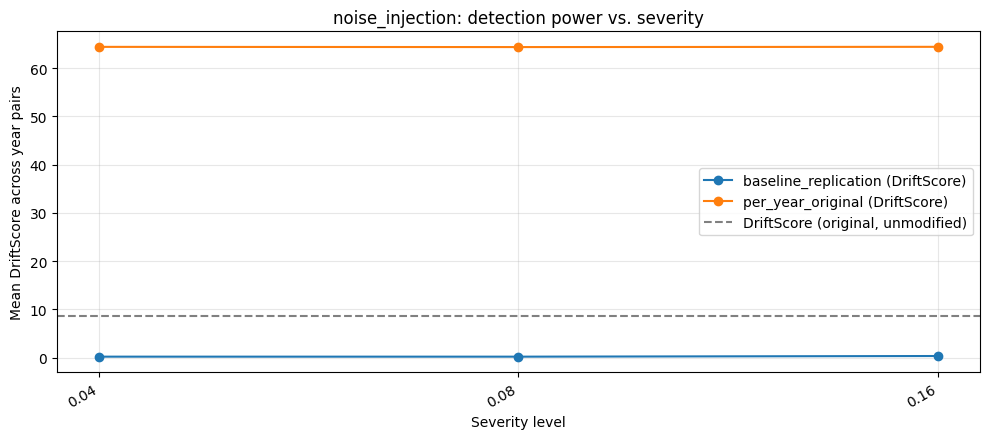

In [11]:
section_results["noise_injection"] = run_method_section(
    method_name="noise_injection",
    sample_fraction=SAMPLE_FRACTION,
    max_samples_per_year=MAX_SAMPLES_PER_YEAR,
 )

noise_combined = section_results["noise_injection"]["combined"]
noise_summary = summarize_and_plot_section(noise_combined, "noise_injection")

## Cross-Method Summary

Consolidate all method runs into one comparison table and aggregate chart.

Collected rows: 90


,method,mode,severity_display,pair,year_t_minus_1,year_t,mmd_rbf_stat,mmd_lap_stat,energy_stat,DriftScore
0,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2017 vs 2018,2017,2018,0.000152,0.000387,0.000118,0.238656
1,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2018 vs 2019,2018,2019,0.000506,-0.000172,-0.000041,0.238656
2,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2019 vs 2020,2019,2020,0.000406,0.000650,-0.000134,0.853288
3,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2020 vs 2021,2020,2021,-0.000180,0.000247,-0.000294,0.238656
4,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2021 vs 2022,2021,2022,0.000281,0.000361,-0.000031,0.238656


Method/mode/severity summary:


,method,mode,severity_display,DriftScore,n_pairs,"DriftScore (original, unmodified)"
0,covariance_shift,baseline_replication,0.05,0.227067,5,NaN
1,covariance_shift,baseline_replication,0.15,0.227067,5,NaN
2,covariance_shift,baseline_replication,0.3,0.227067,5,NaN
3,covariance_shift,per_year_original,0.05,64.453625,5,8.569721
4,covariance_shift,per_year_original,0.15,64.412421,5,8.569721
5,covariance_shift,per_year_original,0.3,64.386251,5,8.569721
6,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",0.361582,5,NaN
7,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.0",10.977209,5,NaN
8,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.15",6.563786,5,NaN
9,mean_variance_shift,per_year_original,"mean_shift=0.0, variance_scale=1.15",65.289684,5,8.569721


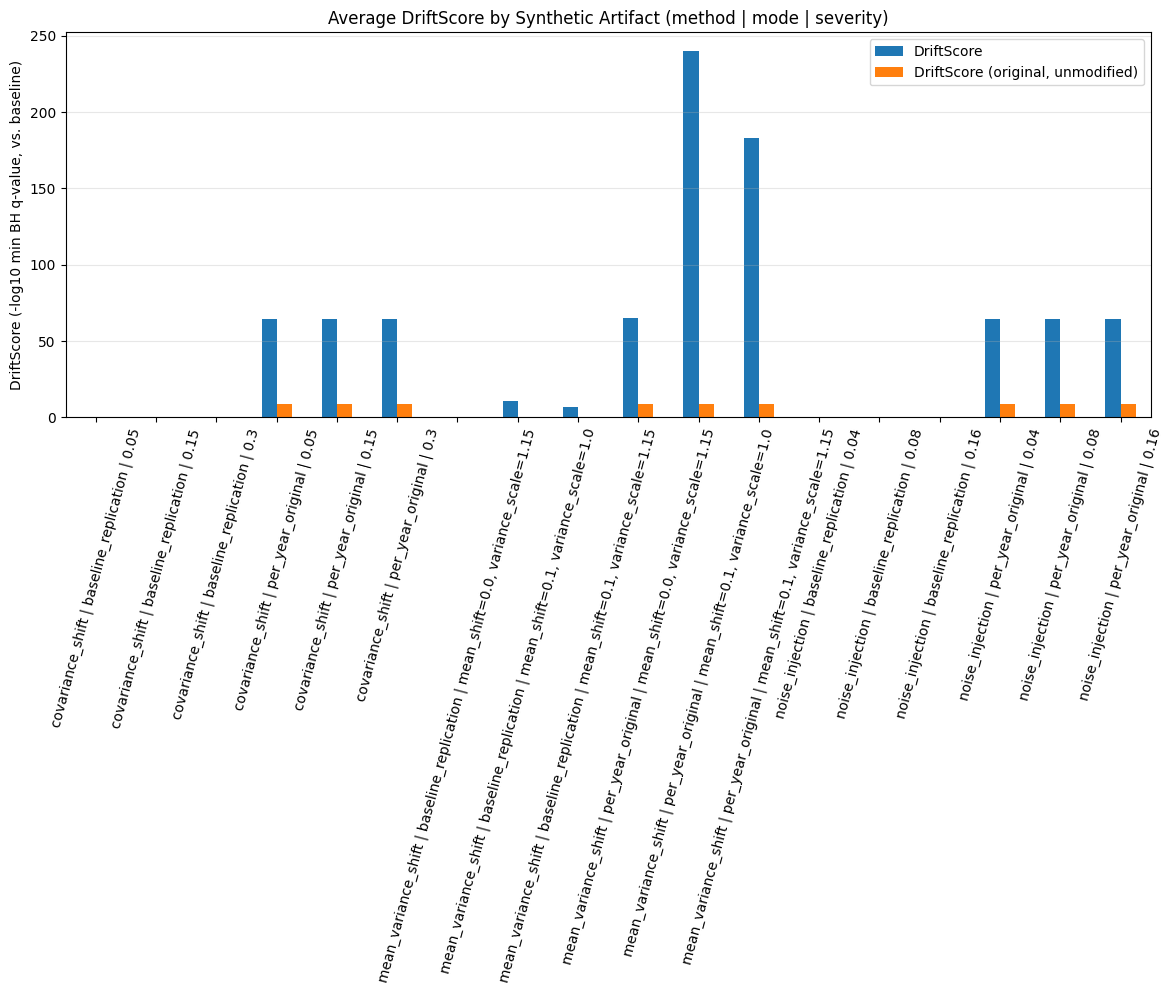

In [12]:
available = {
    k: v for k, v in section_results.items()
    if isinstance(v, dict) and not v.get("combined", pd.DataFrame()).empty
}

if not available:
    print("No method results available yet. Run the method section cells first.")
else:
    all_results = pd.concat([v["combined"] for v in available.values()], ignore_index=True)
    print(f"Collected rows: {len(all_results)}")
    display(
        to_dist_display(
            all_results, ["method", "mode", "severity_display", "pair", "year_t_minus_1", "year_t"]
        ).head()
    )

    summary = (
        all_results.groupby(["method", "mode", "severity_display"], as_index=False, sort=False)
        .agg(
            mean_detection_score=("detection_score", "mean"),
            n_pairs=("pair", "count"),
        )
        .sort_values(["method", "mode"], kind="stable")
        .reset_index(drop=True)
    )

    print("Method/mode/severity summary:")
    plot_df = summary.rename(columns={"mean_detection_score": "DriftScore"})
    is_pyo = plot_df["mode"] == "per_year_original"
    if original_reference_mean_score is not None and is_pyo.any():
        plot_df.loc[is_pyo, "DriftScore (original, unmodified)"] = original_reference_mean_score
    display(plot_df)

    # x-axis is one bar per (method, mode, severity) artifact - averaging away severity here
    # would hide the whole point of the sweep.
    plot_df["artifact_label"] = (
        plot_df["method"] + " | " + plot_df["mode"] + " | " + plot_df["severity_display"]
    )
    bar_cols = [c for c in ["DriftScore", "DriftScore (original, unmodified)"] if c in plot_df.columns]
    ax = plot_df.plot(
        x="artifact_label",
        y=bar_cols,
        kind="bar",
        figsize=(14, 5),
        rot=75,
        title="Average DriftScore by Synthetic Artifact (method | mode | severity)",
    )
    ax.set_xlabel("")
    ax.set_ylabel("DriftScore (-log10 min BH q-value, vs. baseline)")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()